In [ ]:
# Load TBB08 data
import os
import numpy as np
import re
from datetime import datetime, timedelta
def load_and_interpolate_npy(folder_path, interval_minutes=20):
    pattern = re.compile(r"tbb08_(\d{8})_(\d+)\.npy")
    raw_data_stack = []
    raw_datetime_list = []
    # --- 1. Load Data and Timestamps ---
    print(f"--- 1. Loading data from '{folder_path}' ---")
    for filename in sorted(os.listdir(folder_path)):
        if filename.endswith(".npy"):
            match = pattern.match(filename)
            if match:
                date_str, time_str = match.groups()
                time_str = time_str.zfill(4)
                try:
                    dt = datetime.strptime(date_str + time_str, "%Y%m%d%H%M")
                    # CRITICAL: Load the data and append it
                    file_path = os.path.join(folder_path, filename)
                    data = np.load(file_path)
                    raw_data_stack.append(data)
                    raw_datetime_list.append(dt)
                except ValueError:
                    print(f"Skipping file with unparseable time format: {filename}")
                except FileNotFoundError:
                    print(f"Skipping file not found: {filename}")
    if not raw_data_stack:
        print("No valid data files found.")
        return np.array([]), []
    raw_data_array = np.stack(raw_data_stack, axis=0)
    print(f"✅ Loaded {len(raw_datetime_list)} initial data points.")
    print("-" * 40)
    raw_data_array = np.where(raw_data_array < 0, np.nan, raw_data_array)
    print(np.nanmax(raw_data_array))
    print(np.nanmin(raw_data_array))
    mean_raw_data_array = np.nanmean(raw_data_array)
    print(mean_raw_data_array)
    raw_data_array = np.where(np.isnan(raw_data_array), mean_raw_data_array, raw_data_array)
    print(np.max(raw_data_array))
    print(np.min(raw_data_array))
    # --- 2. Check for Missing Data and Prepare for Interpolation ---
    print(f"--- 2. Checking for missing data (Interval: {interval_minutes} min) ---")
    interval = timedelta(minutes=interval_minutes)
    complete_datetime_list = [raw_datetime_list[0]]
    # An array to hold the index of the corresponding raw data point, or -1 for missing
    data_indices = [0]
    current_raw_idx = 1
    # Iterate from the second timestamp
    for i in range(1, len(raw_datetime_list)):
        expected_dt = complete_datetime_list[-1] + interval
        actual_dt = raw_datetime_list[i]
        # Fill any gaps
        while expected_dt < actual_dt:
            print(f"⚠️ Missing data point at: {expected_dt.strftime('%Y%m%d %H%M')}")
            complete_datetime_list.append(expected_dt)
            data_indices.append(-1)  # Mark as missing, needs interpolation
            expected_dt += interval
        # If the actual data matches the next expected interval
        if expected_dt == actual_dt:
            complete_datetime_list.append(actual_dt)
            data_indices.append(i) # Mark with the index of the raw data
        # If the file is a duplicate or an unexpected timestamp (skip it)
        # Note: If there are significant deviations, the logic may need adjustment
        # For simplicity, we assume files are mostly in order and close to the interval.
        current_raw_idx = i
    print(f"Total data points (raw + missing): {len(complete_datetime_list)}")
    print("-" * 40)
    # --- 3. Perform Temporal Interpolation ---
    print("--- 3. Performing Linear Temporal Interpolation ---")
    interpolated_data_list = []
    # Track the last and next *available* raw data points for interpolation
    last_known_idx = 0
    for i, data_idx in enumerate(data_indices):
        if data_idx != -1:
            # Data is present (raw data)
            interpolated_data_list.append(raw_data_array[data_idx])
            last_known_idx = data_idx
        else:
            # Data is missing (needs interpolation)
            # Find the *next* known data point (j)
            next_known_idx = -1
            for j in range(i + 1, len(data_indices)):
                if data_indices[j] != -1:
                    # Found the index into the raw_data_array
                    next_known_idx = data_indices[j] 
                    break
            if next_known_idx != -1:
                # Perform linear interpolation between the two known points
                t_last = raw_datetime_list[last_known_idx]
                t_next = raw_datetime_list[next_known_idx]
                t_miss = complete_datetime_list[i]
                # Convert time differences to total seconds for ratio calculation
                total_duration = (t_next - t_last).total_seconds()
                time_elapsed = (t_miss - t_last).total_seconds()
                # Check for zero duration (shouldn't happen with correct interval logic)
                if total_duration == 0:
                    interp_data = raw_data_array[last_known_idx] # Fallback
                else:
                    ratio = time_elapsed / total_duration
                    data_last = raw_data_array[last_known_idx]
                    data_next = raw_data_array[next_known_idx]
                    # Linear interpolation: Data_miss = Data_last + ratio * (Data_next - Data_last)
                    interp_data = data_last + ratio * (data_next - data_last)
                interpolated_data_list.append(interp_data)
            else:
                # No subsequent data, use the last known data (extrapolation/hold)
                print(f"🛑 Cannot interpolate at {t_miss.strftime('%Y%m%d %H%M')}. No following data.")
                interpolated_data_list.append(raw_data_array[last_known_idx])
    interpolated_data_array = np.stack(interpolated_data_list, axis=0)
    print("✅ Interpolation complete.")
    return interpolated_data_array, complete_datetime_list
# Continue from your existing Example Usage:
folder = "tbb_08_npy_files_cropped"
tbb08, times_interp = load_and_interpolate_npy(folder, interval_minutes=10)
print("\n--- Results ---")
print(f"Interpolated Data Shape: {tbb08.shape}")
if times_interp:
    print(f"First timestamp: {times_interp[0].strftime('%Y-%m-%d %H:%M')}")
    print(f"Last timestamp: {times_interp[-1].strftime('%Y-%m-%d %H:%M')}")
    print("-" * 20)
    # --- Example: Find data for a specific time ---
    target_date = datetime(2023, 11, 25, 12, 40) # Example target: Nov 25, 2023, 12:40 PM
    try:
        # Find the index of the target date in the list
        target_index = times_interp.index(target_date) 
        print(f"Data for {target_date.strftime('%Y-%m-%d %H:%M')}:")
        print(tbb08[target_index])
    except ValueError:
        print(f"Timestamp {target_date.strftime('%Y-%m-%d %H:%M')} not found in the complete list.")
tbb08 = np.where(tbb08 < 0, np.nan, tbb08)
print(np.nanmax(tbb08))
print(np.nanmin(tbb08))
mean_tbb08 = np.nanmean(tbb08)
print(mean_tbb08)
tbb08 = np.where(np.isnan(tbb08), 251.68286, tbb08)
print(np.max(tbb08))
print(np.min(tbb08))
print(tbb08.shape)
print(len(times_interp))
# Convert the list of datetime objects to a NumPy array with dtype datetime64
datetime_tbb  = np.array(times_interp, dtype=np.datetime64)
print(datetime_tbb.shape)


In [ ]:
# Load TBB09 data
import os
import numpy as np
import re
from datetime import datetime, timedelta
def load_and_interpolate_npy(folder_path, interval_minutes=20):
    pattern = re.compile(r"tbb09_(\d{8})_(\d+)\.npy")
    raw_data_stack = []
    raw_datetime_list = []
    # --- 1. Load Data and Timestamps ---
    print(f"--- 1. Loading data from '{folder_path}' ---")
    for filename in sorted(os.listdir(folder_path)):
        if filename.endswith(".npy"):
            match = pattern.match(filename)
            if match:
                date_str, time_str = match.groups()
                time_str = time_str.zfill(4)
                try:
                    dt = datetime.strptime(date_str + time_str, "%Y%m%d%H%M")
                    # CRITICAL: Load the data and append it
                    file_path = os.path.join(folder_path, filename)
                    data = np.load(file_path)
                    raw_data_stack.append(data)
                    raw_datetime_list.append(dt)
                except ValueError:
                    print(f"Skipping file with unparseable time format: {filename}")
                except FileNotFoundError:
                    print(f"Skipping file not found: {filename}")
    if not raw_data_stack:
        print("No valid data files found.")
        return np.array([]), []
    raw_data_array = np.stack(raw_data_stack, axis=0)
    print(f"✅ Loaded {len(raw_datetime_list)} initial data points.")
    print("-" * 40)
    raw_data_array = np.where(raw_data_array < 0, np.nan, raw_data_array)
    print(np.nanmax(raw_data_array))
    print(np.nanmin(raw_data_array))
    mean_raw_data_array = np.nanmean(raw_data_array)
    print(mean_raw_data_array)
    raw_data_array = np.where(np.isnan(raw_data_array), mean_raw_data_array, raw_data_array)
    print(np.max(raw_data_array))
    print(np.min(raw_data_array))
    # --- 2. Check for Missing Data and Prepare for Interpolation ---
    print(f"--- 2. Checking for missing data (Interval: {interval_minutes} min) ---")
    interval = timedelta(minutes=interval_minutes)
    complete_datetime_list = [raw_datetime_list[0]]
    # An array to hold the index of the corresponding raw data point, or -1 for missing
    data_indices = [0]
    current_raw_idx = 1
    # Iterate from the second timestamp
    for i in range(1, len(raw_datetime_list)):
        expected_dt = complete_datetime_list[-1] + interval
        actual_dt = raw_datetime_list[i]
        # Fill any gaps
        while expected_dt < actual_dt:
            print(f"⚠️ Missing data point at: {expected_dt.strftime('%Y%m%d %H%M')}")
            complete_datetime_list.append(expected_dt)
            data_indices.append(-1)  # Mark as missing, needs interpolation
            expected_dt += interval
        # If the actual data matches the next expected interval
        if expected_dt == actual_dt:
            complete_datetime_list.append(actual_dt)
            data_indices.append(i) # Mark with the index of the raw data
        # If the file is a duplicate or an unexpected timestamp (skip it)
        # Note: If there are significant deviations, the logic may need adjustment
        # For simplicity, we assume files are mostly in order and close to the interval.
        current_raw_idx = i
    print(f"Total data points (raw + missing): {len(complete_datetime_list)}")
    print("-" * 40)
    # --- 3. Perform Temporal Interpolation ---
    print("--- 3. Performing Linear Temporal Interpolation ---")
    interpolated_data_list = []
    # Track the last and next *available* raw data points for interpolation
    last_known_idx = 0
    for i, data_idx in enumerate(data_indices):
        if data_idx != -1:
            # Data is present (raw data)
            interpolated_data_list.append(raw_data_array[data_idx])
            last_known_idx = data_idx
        else:
            # Data is missing (needs interpolation)
            # Find the *next* known data point (j)
            next_known_idx = -1
            for j in range(i + 1, len(data_indices)):
                if data_indices[j] != -1:
                    # Found the index into the raw_data_array
                    next_known_idx = data_indices[j] 
                    break
            if next_known_idx != -1:
                # Perform linear interpolation between the two known points
                t_last = raw_datetime_list[last_known_idx]
                t_next = raw_datetime_list[next_known_idx]
                t_miss = complete_datetime_list[i]
                # Convert time differences to total seconds for ratio calculation
                total_duration = (t_next - t_last).total_seconds()
                time_elapsed = (t_miss - t_last).total_seconds()
                # Check for zero duration (shouldn't happen with correct interval logic)
                if total_duration == 0:
                    interp_data = raw_data_array[last_known_idx] # Fallback
                else:
                    ratio = time_elapsed / total_duration
                    data_last = raw_data_array[last_known_idx]
                    data_next = raw_data_array[next_known_idx]
                    # Linear interpolation: Data_miss = Data_last + ratio * (Data_next - Data_last)
                    interp_data = data_last + ratio * (data_next - data_last)
                interpolated_data_list.append(interp_data)
            else:
                # No subsequent data, use the last known data (extrapolation/hold)
                print(f"🛑 Cannot interpolate at {t_miss.strftime('%Y%m%d %H%M')}. No following data.")
                interpolated_data_list.append(raw_data_array[last_known_idx])
    interpolated_data_array = np.stack(interpolated_data_list, axis=0)
    print("✅ Interpolation complete.")
    return interpolated_data_array, complete_datetime_list
# Continue from your existing Example Usage:
folder = "tbb_09_npy_files_cropped"
tbb09, times_interp = load_and_interpolate_npy(folder, interval_minutes=10)
print("\n--- Results ---")
print(f"Interpolated Data Shape: {tbb09.shape}")
if times_interp:
    print(f"First timestamp: {times_interp[0].strftime('%Y-%m-%d %H:%M')}")
    print(f"Last timestamp: {times_interp[-1].strftime('%Y-%m-%d %H:%M')}")
    print("-" * 20)
    # --- Example: Find data for a specific time ---
    target_date = datetime(2023, 11, 25, 12, 40) # Example target: Nov 25, 2023, 12:40 PM
    try:
        # Find the index of the target date in the list
        target_index = times_interp.index(target_date) 
        print(f"Data for {target_date.strftime('%Y-%m-%d %H:%M')}:")
        print(tbb09[target_index])
    except ValueError:
        print(f"Timestamp {target_date.strftime('%Y-%m-%d %H:%M')} not found in the complete list.")
tbb09 = np.where(tbb09 < 0, np.nan, tbb09)
print(np.nanmax(tbb09))
print(np.nanmin(tbb09))
mean_tbb08 = np.nanmean(tbb09)
print(mean_tbb08)
tbb09 = np.where(np.isnan(tbb09), 251.68286, tbb09)
print(np.max(tbb09))
print(np.min(tbb09))
print(tbb09.shape)
print(len(times_interp))
# Convert the list of datetime objects to a NumPy array with dtype datetime64
datetime_tbb  = np.array(times_interp, dtype=np.datetime64)
print(datetime_tbb.shape)


In [ ]:
# Load TBB10 data
import os
import numpy as np
import re
from datetime import datetime, timedelta
def load_and_interpolate_npy(folder_path, interval_minutes=20):
    pattern = re.compile(r"tbb10_(\d{8})_(\d+)\.npy")
    raw_data_stack = []
    raw_datetime_list = []
    # --- 1. Load Data and Timestamps ---
    print(f"--- 1. Loading data from '{folder_path}' ---")
    for filename in sorted(os.listdir(folder_path)):
        if filename.endswith(".npy"):
            match = pattern.match(filename)
            if match:
                date_str, time_str = match.groups()
                time_str = time_str.zfill(4)
                try:
                    dt = datetime.strptime(date_str + time_str, "%Y%m%d%H%M")
                    # CRITICAL: Load the data and append it
                    file_path = os.path.join(folder_path, filename)
                    data = np.load(file_path)
                    raw_data_stack.append(data)
                    raw_datetime_list.append(dt)
                except ValueError:
                    print(f"Skipping file with unparseable time format: {filename}")
                except FileNotFoundError:
                    print(f"Skipping file not found: {filename}")
    if not raw_data_stack:
        print("No valid data files found.")
        return np.array([]), []
    raw_data_array = np.stack(raw_data_stack, axis=0)
    print(f"✅ Loaded {len(raw_datetime_list)} initial data points.")
    print("-" * 40)
    raw_data_array = np.where(raw_data_array < 0, np.nan, raw_data_array)
    print(np.nanmax(raw_data_array))
    print(np.nanmin(raw_data_array))
    mean_raw_data_array = np.nanmean(raw_data_array)
    print(mean_raw_data_array)
    raw_data_array = np.where(np.isnan(raw_data_array), mean_raw_data_array, raw_data_array)
    print(np.max(raw_data_array))
    print(np.min(raw_data_array))
    # --- 2. Check for Missing Data and Prepare for Interpolation ---
    print(f"--- 2. Checking for missing data (Interval: {interval_minutes} min) ---")
    interval = timedelta(minutes=interval_minutes)
    complete_datetime_list = [raw_datetime_list[0]]
    # An array to hold the index of the corresponding raw data point, or -1 for missing
    data_indices = [0]
    current_raw_idx = 1
    # Iterate from the second timestamp
    for i in range(1, len(raw_datetime_list)):
        expected_dt = complete_datetime_list[-1] + interval
        actual_dt = raw_datetime_list[i]
        # Fill any gaps
        while expected_dt < actual_dt:
            print(f"⚠️ Missing data point at: {expected_dt.strftime('%Y%m%d %H%M')}")
            complete_datetime_list.append(expected_dt)
            data_indices.append(-1)  # Mark as missing, needs interpolation
            expected_dt += interval
        # If the actual data matches the next expected interval
        if expected_dt == actual_dt:
            complete_datetime_list.append(actual_dt)
            data_indices.append(i) # Mark with the index of the raw data
        # If the file is a duplicate or an unexpected timestamp (skip it)
        # Note: If there are significant deviations, the logic may need adjustment
        # For simplicity, we assume files are mostly in order and close to the interval.
        current_raw_idx = i
    print(f"Total data points (raw + missing): {len(complete_datetime_list)}")
    print("-" * 40)
    # --- 3. Perform Temporal Interpolation ---
    print("--- 3. Performing Linear Temporal Interpolation ---")
    interpolated_data_list = []
    # Track the last and next *available* raw data points for interpolation
    last_known_idx = 0
    for i, data_idx in enumerate(data_indices):
        if data_idx != -1:
            # Data is present (raw data)
            interpolated_data_list.append(raw_data_array[data_idx])
            last_known_idx = data_idx
        else:
            # Data is missing (needs interpolation)
            # Find the *next* known data point (j)
            next_known_idx = -1
            for j in range(i + 1, len(data_indices)):
                if data_indices[j] != -1:
                    # Found the index into the raw_data_array
                    next_known_idx = data_indices[j] 
                    break
            if next_known_idx != -1:
                # Perform linear interpolation between the two known points
                t_last = raw_datetime_list[last_known_idx]
                t_next = raw_datetime_list[next_known_idx]
                t_miss = complete_datetime_list[i]
                # Convert time differences to total seconds for ratio calculation
                total_duration = (t_next - t_last).total_seconds()
                time_elapsed = (t_miss - t_last).total_seconds()
                # Check for zero duration (shouldn't happen with correct interval logic)
                if total_duration == 0:
                    interp_data = raw_data_array[last_known_idx] # Fallback
                else:
                    ratio = time_elapsed / total_duration
                    data_last = raw_data_array[last_known_idx]
                    data_next = raw_data_array[next_known_idx]
                    # Linear interpolation: Data_miss = Data_last + ratio * (Data_next - Data_last)
                    interp_data = data_last + ratio * (data_next - data_last)
                interpolated_data_list.append(interp_data)
            else:
                # No subsequent data, use the last known data (extrapolation/hold)
                print(f"🛑 Cannot interpolate at {t_miss.strftime('%Y%m%d %H%M')}. No following data.")
                interpolated_data_list.append(raw_data_array[last_known_idx])
    interpolated_data_array = np.stack(interpolated_data_list, axis=0)
    print("✅ Interpolation complete.")
    return interpolated_data_array, complete_datetime_list
# Continue from your existing Example Usage:
folder = "tbb_10_npy_files_cropped"
tbb10, times_interp = load_and_interpolate_npy(folder, interval_minutes=10)
print("\n--- Results ---")
print(f"Interpolated Data Shape: {tbb10.shape}")
if times_interp:
    print(f"First timestamp: {times_interp[0].strftime('%Y-%m-%d %H:%M')}")
    print(f"Last timestamp: {times_interp[-1].strftime('%Y-%m-%d %H:%M')}")
    print("-" * 20)
    # --- Example: Find data for a specific time ---
    target_date = datetime(2023, 11, 25, 12, 40) # Example target: Nov 25, 2023, 12:40 PM
    try:
        # Find the index of the target date in the list
        target_index = times_interp.index(target_date) 
        print(f"Data for {target_date.strftime('%Y-%m-%d %H:%M')}:")
        print(tbb10[target_index])
    except ValueError:
        print(f"Timestamp {target_date.strftime('%Y-%m-%d %H:%M')} not found in the complete list.")
tbb10 = np.where(tbb10 < 0, np.nan, tbb10)
print(np.nanmax(tbb10))
print(np.nanmin(tbb10))
mean_tbb08 = np.nanmean(tbb10)
print(mean_tbb08)
tbb10 = np.where(np.isnan(tbb10), 251.68286, tbb10)
print(np.max(tbb10))
print(np.min(tbb10))
print(tbb10.shape)
print(len(times_interp))
# Convert the list of datetime objects to a NumPy array with dtype datetime64
datetime_tbb  = np.array(times_interp, dtype=np.datetime64)
print(datetime_tbb.shape)


In [4]:
from collections import Counter
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import numpy as np
import pandas as pd
# ============================================================
# 1. LOAD GRID & SATELLITE (TBB) METADATA
# ============================================================
ds = Dataset('H08_20180706_0250_RFL021_FLDK.02401_02401.nc')
lat = ds.variables['latitude'][:]
lon = ds.variables['longitude'][:]
lat_min, lat_max = 30.00, 36.00
lon_min, lon_max = 128.80, 137.00
lat = lat[(lat >= lat_min) & (lat <= lat_max)]
lon = lon[(lon >= lon_min) & (lon <= lon_max)]
# Grid orientation check
flip_lat = lat[0] > lat[-1]
lat_used = lat[::-1] if flip_lat else lat
lat2d, lon2d = np.meshgrid(lat_used, lon, indexing='ij')
# Format satellite TBB timestamps
datetime_tbb = pd.to_datetime(datetime_tbb).round('1min')
tbb_time_index = pd.Series(np.arange(len(datetime_tbb)), index=datetime_tbb)
# ============================================================
# 2. HELPER FUNCTION TO LOAD & PREPROCESS GPS DATA
# ============================================================
def load_and_clean_gps(filepath, lat_min, lat_max, lon_min, lon_max):
  df = pd.read_csv(filepath, low_memory=False)
  # Clean column headers and station names
  df.columns = df.columns.str.strip()
  df['E_NAME'] = df['E_NAME'].astype(str).str.strip()
  # Identify coordinate column names
  lat_col = 'lat_deg' if 'lat_deg' in df.columns else 'LAT'
  lon_col = 'lon_deg' if 'lon_deg' in df.columns else 'LON'
  # Parse 3-hourly msm_time column
  df['msm_time'] = pd.to_datetime(df['msm_time']).dt.floor('1min')
  # Spatial Bounding Box Filter
  df = df[
      (df[lat_col] >= lat_min)
      & (df[lat_col] <= lat_max)
      & (df[lon_col] >= lon_min)
      & (df[lon_col] <= lon_max)
  ].copy()
  # Filter unphysical PWV values
  df = df[df['PWV'] > 0].copy()
  # Deduplicate on Station + 3-hourly msm_time
  df = df.drop_duplicates(subset=['E_NAME', 'msm_time']).copy()
  return df, lat_col, lon_col
# Load both years
GPS_2018_raw, lat_col18, lon_col18 = load_and_clean_gps(
    'result_with_PWV.csv', lat_min, lat_max, lon_min, lon_max
)
GPS_2019_raw, lat_col19, lon_col19 = load_and_clean_gps(
    'result_with_PWV_2019.csv', lat_min, lat_max, lon_min, lon_max
)
# ============================================================
# 3. BUILD 3-HOURLY TIME AXIS & MATCH STATIONS ACROSS YEARS
# ============================================================
# Common 3-hourly timestamps between 2018 GPS and Satellite TBB
common_times_2018 = sorted(
    set(GPS_2018_raw['msm_time']).intersection(set(tbb_time_index.index))
)
times_ref_2018 = pd.DatetimeIndex(common_times_2018)
times_ref_2019 = times_ref_2018 + pd.DateOffset(years=1)
# Pivot DataFrames to [Stations x 3-hourly Time Steps]
pivot_2018 = GPS_2018_raw.pivot_table(
    index='E_NAME', columns='msm_time', values='PWV', aggfunc='mean'
).reindex(columns=times_ref_2018)
pivot_2019 = GPS_2019_raw.pivot_table(
    index='E_NAME', columns='msm_time', values='PWV', aggfunc='mean'
).reindex(columns=times_ref_2019)
# Filter stations that have 100% COMPLETE data across ALL time steps in BOTH years
stns_valid_18 = pivot_2018.dropna(axis=0).index
stns_valid_19 = pivot_2019.dropna(axis=0).index
good_sites = sorted(list(set(stns_valid_18).intersection(set(stns_valid_19))))
pivot_2018_final = pivot_2018.loc[good_sites]
pivot_2019_final = pivot_2019.loc[good_sites]
# Station spatial coordinates
coords_2018 = GPS_2018_raw.groupby('E_NAME')[
    [lat_col18, lon_col18]
].first().loc[good_sites]
# ============================================================
# 4. EXTRACTION OF 1D CONCATENATED ARRAYS & SATELLITE TBB
# ============================================================
pwv_all, pwv_all_2019 = [], []
tbb08_all, tbb09_all, tbb10_all = [], [], []
idx_model = tbb_time_index.loc[times_ref_2018].values
for site in good_sites:
  lat_site = coords_2018.loc[site, lat_col18]
  lon_site = coords_2018.loc[site, lon_col18]
  dist2 = (lat2d - lat_site) ** 2 + (lon2d - lon_site) ** 2
  i, j = np.unravel_index(np.argmin(dist2), dist2.shape)
  if flip_lat:
    i = len(lat) - 1 - i
  # Extract matching satellite TBB pixels
  tbb08_c = np.asarray(tbb08[idx_model, i, j]).flatten()
  tbb09_c = np.asarray(tbb09[idx_model, i, j]).flatten()
  tbb10_c = np.asarray(tbb10[idx_model, i, j]).flatten()
  # Extract 3-hourly PWV vectors
  pwv_c = pivot_2018_final.loc[site].values.flatten()
  pwv_c1 = pivot_2019_final.loc[site].values.flatten()
  pwv_all.append(pwv_c)
  pwv_all_2019.append(pwv_c1)
  tbb08_all.append(tbb08_c)
  tbb09_all.append(tbb09_c)
  tbb10_all.append(tbb10_c)
pwv_all = np.concatenate(pwv_all)
pwv_all_2019 = np.concatenate(pwv_all_2019)
tbb08_all = np.concatenate(tbb08_all)
tbb09_all = np.concatenate(tbb09_all)
tbb10_all = np.concatenate(tbb10_all)
# ============================================================
# 5. VERIFICATION & TIMELINE DIAGNOSTICS
# ============================================================
time_diffs = pd.Series(times_ref_2018).diff().dropna().unique()
print('=' * 60)
print('             DATASET VERIFICATION REPORT')
print('=' * 60)
print(f'2018 Start Time         : {times_ref_2018.min()}')
print(f'2018 End Time           : {times_ref_2018.max()}')
print(f'2019 Start Time         : {times_ref_2019.min()}')
print(f'2019 End Time           : {times_ref_2019.max()}')
print(f'Time Step Intervals     : {time_diffs}')
print(f'Is Strictly 3-Hourly?   : {(time_diffs == pd.Timedelta("3h")).all()}')
print('-' * 60)
print(f'Total Time Steps (T)    : {len(times_ref_2018)}')
print(f'Synchronized Stations   : {len(good_sites)}')
print('-' * 60)
expected_pts = len(good_sites) * len(times_ref_2018)
print(f'Total 2018 PWV Points   : {len(pwv_all)} (Expected: {expected_pts})')
print(
    f'Total 2019 PWV Points   : {len(pwv_all_2019)} (Expected: {expected_pts})'
)
print(f'Total TBB08 Points      : {len(tbb08_all)}')
print(f'Any NaN in 2018 PWV?    : {np.isnan(pwv_all).any()}')
print(f'Any NaN in 2019 PWV?    : {np.isnan(pwv_all_2019).any()}')
print('=' * 60)

/home/nyoman/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/nyoman/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/nyoman/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


             DATASET VERIFICATION REPORT
2018 Start Time         : 2018-06-01 00:00:00
2018 End Time           : 2018-10-31 06:00:00
2019 Start Time         : 2019-06-01 00:00:00
2019 End Time           : 2019-10-31 06:00:00
Time Step Intervals     : <TimedeltaArray>
['0 days 03:00:00']
Length: 1, dtype: timedelta64[ns]
Is Strictly 3-Hourly?   : True
------------------------------------------------------------
Total Time Steps (T)    : 1219
Synchronized Stations   : 445
------------------------------------------------------------
Total 2018 PWV Points   : 542455 (Expected: 542455)
Total 2019 PWV Points   : 542455 (Expected: 542455)
Total TBB08 Points      : 542455
Any NaN in 2018 PWV?    : False
Any NaN in 2019 PWV?    : False


(121, 165)


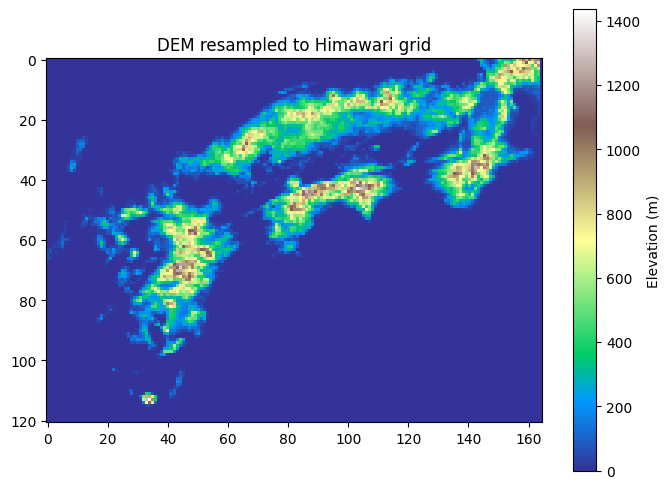

In [5]:
# Load DEM Data
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
with rasterio.open("cropped_dem.tif") as dem_src:
    dem_data = dem_src.read(1)
    dem_transform = dem_src.transform
    dem_crs = dem_src.crs
# Satellite grid resolution
lat_res = abs(lat[1] - lat[0])
lon_res = abs(lon[1] - lon[0])

# Upper-left corner
west = lon.min()
north = lat.max()

from affine import Affine
target_transform = Affine.translation(west, north) * Affine.scale(lon_res, -lat_res)

target_shape = (len(lat), len(lon))  # (121, 165)
dem_coarse = np.zeros(target_shape, dtype=np.float32)
reproject(
    source=dem_data,
    destination=dem_coarse,
    src_transform=dem_transform,
    src_crs=dem_crs,
    dst_transform=target_transform,
    dst_crs=dem_crs,          # same CRS
    resampling=Resampling.average
)
print(dem_coarse.shape)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(dem_coarse, origin='upper', cmap='terrain')
plt.colorbar(label="Elevation (m)")
plt.title("DEM resampled to Himawari grid")
plt.show()


        Pressure_hPa  Relative_Humidity  Temperature  WindSpeed  \
60400           1000               73.0          6.6        2.0   
60401            925               27.0          8.9        8.0   
60402            900               40.0          7.6        7.0   
60403            850               39.0          4.1        5.0   
60404            800               15.0          2.9        6.0   
...              ...                ...          ...        ...   
121220            30                NaN        -55.5        5.0   
121221            20                NaN        -54.1        2.0   
121222            15                NaN        -49.6        4.0   
121223            10                NaN          NaN        NaN   
121224             5                NaN          NaN        NaN   

        WindDirection  latitude   longitude            datetime  elevation  \
60400            44.0    45.415  141.678333 2018-06-01 09:00:00        2.0   
60401            69.0    45.415  141.67

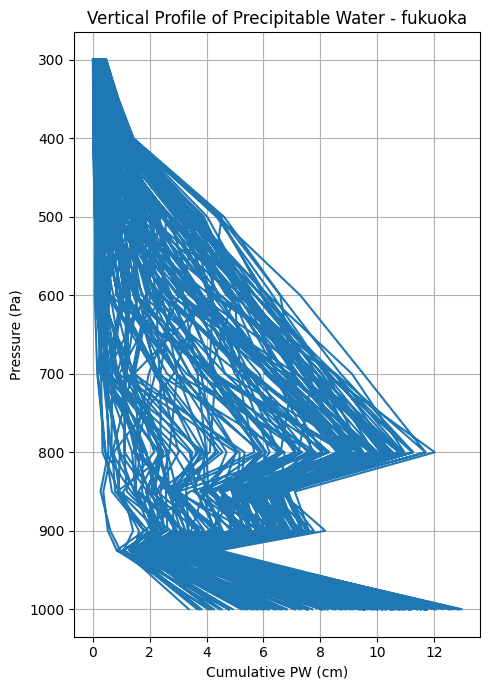

         date         PW   latitude   longitude
0  2018-06-01  16.945286  33.583333  130.383333
1  2018-06-02  16.220477  33.583333  130.383333
2  2018-06-03  20.181711  33.583333  130.383333
3  2018-06-04  24.722761  33.583333  130.383333
4  2018-06-05  46.006126  33.583333  130.383333
         date         PW  latitude   longitude
0  2018-06-01  15.102338    31.555  130.548333
1  2018-06-02  13.146084    31.555  130.548333
2  2018-06-03  19.166535    31.555  130.548333
3  2018-06-04  26.353941    31.555  130.548333
4  2018-06-05  51.558857    31.555  130.548333
         date         PW   latitude   longitude
0  2018-06-01  18.324131  35.458333  133.066667
1  2018-06-02  13.553276  35.458333  133.066667
2  2018-06-03  12.838909  35.458333  133.066667
3  2018-06-04  19.005257  35.458333  133.066667
4  2018-06-05  33.125580  35.458333  133.066667
         date         PW   latitude   longitude
0  2018-06-01  17.048171  33.451667  135.761667
1  2018-06-02  17.281587  33.451667  135.76166

In [6]:
# Radiosonde
import pandas as pd
import numpy as np
# CSV読み込み
data = pd.read_csv('radiosonde_data_20180101_to_20190101_siteikiatu.csv') #/media/wrf/e50c04f2-f8eb-4a3f-85f1-e82d1803b4e0/hirao/radiosonde/radiosonde_data_20180101_to_20190101_siteikiatu.csv
data.replace('///', np.nan, inplace=True)
# 数値型に変換するカラム（datetime を除く）
columns_to_convert = ['Pressure_hPa', 'Relative_Humidity', 'Temperature', 'WindSpeed', 'WindDirection', 'latitude', 'longitude']
for column in columns_to_convert:
    data[column] = pd.to_numeric(data[column], errors='coerce')
# datetime 列を日付時刻型に変換
data['datetime'] = pd.to_datetime(data['datetime'], errors='coerce')
# pointごとの標高辞書を作成（例）
elevation_dict = {
    47401: 2.0,      # wakanai
    47412: 17.1,     # sapporo
    47418: 4.5,      # kusiro
    47582: 5.8,     # akita
    47600: 5.4,     # wajima
    47646: 22.5,     # tateno
    47678: 149.1,     # hachijyoujima
    47741: 3.3,     # matsue
    47778: 72.0,     # shionomisaki
    47807: 10.5,     # fukuoka
    47827: 4.0,     # kagoshima
    47909: 280.7,     # naze
    47918: 5.2,     # ishigakijima
    47945: 14.0,     # minamidaitoujima
    47971: 151.0,     # cicijima
    47991: 5.0      # minamitorishima
}
data['elevation'] = data['point'].map(elevation_dict)
# ==== 期間指定 ====
start_time = pd.to_datetime('2018-06-01 00:00')
end_time   = pd.to_datetime('2018-10-31 09:00')
# ==== 期間内のデータに絞り込み ====
data_period = data[(data['datetime'] >= start_time) & (data['datetime'] <= end_time)]
# ==== 観測点ごとにフィルタリング（期間内のすべてのデータ） ====
wakanai = data_period[data_period['point'] == 47401]
sapporo = data_period[data_period['point'] == 47412]
kusiro = data_period[data_period['point'] == 47418]
akita = data_period[data_period['point'] == 47582]
wajima = data_period[data_period['point'] == 47600]
tateno = data_period[data_period['point'] == 47646]
hachijyoujima = data_period[data_period['point'] == 47678]
matsue = data_period[data_period['point'] == 47741]
shionomisaki = data_period[data_period['point'] == 47778]
fukuoka = data_period[data_period['point'] == 47807]
kagoshima = data_period[data_period['point'] == 47827]
naze = data_period[data_period['point'] == 47909]
ishigakijima = data_period[data_period['point'] == 47918]
minamidaitoujima = data_period[data_period['point'] == 47945]
cicijima = data_period[data_period['point'] == 47971]
minamitorishima = data_period[data_period['point'] == 47991]
# 必要な列だけ抽出
columns_needed = ['Pressure_hPa', 'Relative_Humidity', 'Temperature', 'WindSpeed', 'WindDirection',
                  'latitude', 'longitude', 'datetime', 'elevation']
wakanai = wakanai[columns_needed]
sapporo = sapporo[columns_needed]
kusiro = kusiro[columns_needed]
akita = akita[columns_needed]
wajima = wajima[columns_needed]
tateno = tateno[columns_needed]
hachijyoujima = hachijyoujima[columns_needed]
matsue = matsue[columns_needed]
shionomisaki = shionomisaki[columns_needed]
fukuoka = fukuoka[columns_needed]
kagoshima = kagoshima[columns_needed]
naze = naze[columns_needed]
ishigakijima = ishigakijima[columns_needed]
minamidaitoujima = minamidaitoujima[columns_needed]
cicijima = cicijima[columns_needed]
minamitorishima = minamitorishima[columns_needed]
# Add a new column for specific humidity
def calc_sh(sta_name):
    T = sta_name['Temperature']
    RH = sta_name['Relative_Humidity'] / 100
    P = sta_name['Pressure_hPa']  # in hPa
    # Saturation vapor pressure (Pa)
    es = 6.112 * np.exp((17.67 * T) / (T + 243.5)) * 100
    e = RH * es  # Actual vapor pressure (Pa)
    # Specific humidity (kg/kg)
    sta_name['SH'] = (0.622 * e) / (P * 100 - 0.378 * e)
    return sta_name
# Calculate SH
wakanai = calc_sh(wakanai)
sapporo = calc_sh(sapporo)
kusiro = calc_sh(kusiro)
akita = calc_sh(akita)
wajima = calc_sh(wajima)
tateno = calc_sh(tateno)
hachijyoujima = calc_sh(hachijyoujima) 
matsue = calc_sh(matsue)
shionomisaki = calc_sh(shionomisaki)
fukuoka = calc_sh(fukuoka)
kagoshima = calc_sh(kagoshima)
naze = calc_sh(naze)
ishigakijima = calc_sh(ishigakijima)
minamidaitoujima = calc_sh(minamidaitoujima)
cicijima = calc_sh(cicijima)
minamitorishima = calc_sh(minamitorishima)
print(wakanai)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
def calc_layer_pw(df):
    g = 9.80665  # 重力加速度 [m/s^2]
    result_df_list = []
    for dt, group in df.groupby('datetime'):
        group_sorted = group.sort_values('Pressure_hPa', ascending=False).copy()
        group_sorted['Pressure_Pa'] = group_sorted['Pressure_hPa'] * 100  # hPa→Pa
        # 気圧差（上の層 - 下の層）
        group_sorted['delta_p'] = group_sorted['Pressure_Pa'].diff(-1)
        # 次の層の比湿をシフトで取得
        group_sorted['SH_next'] = group_sorted['SH'].shift(-1)
        # 平均比湿を計算（上下2点の平均）
        group_sorted['avg_SH'] = (group_sorted['SH'] + group_sorted['SH_next']) / 2
        # 最下層は平均できないのでNaNになる。PW計算から除外
        group_sorted['PW'] = (group_sorted['avg_SH'] * group_sorted['delta_p']) / g
        result_df_list.append(group_sorted)
    result_df = pd.concat(result_df_list)
    return result_df
# Assuming 'wakanai' already has the 'SH' column
wakanai = calc_layer_pw(wakanai)
sapporo = calc_layer_pw(sapporo)
kusiro = calc_layer_pw(kusiro)
akita = calc_layer_pw(akita)
wajima = calc_layer_pw(wajima)
tateno = calc_layer_pw(tateno)
hachijyoujima = calc_layer_pw(hachijyoujima) 
matsue = calc_layer_pw(matsue)
shionomisaki = calc_layer_pw(shionomisaki)
fukuoka = calc_layer_pw(fukuoka)
kagoshima = calc_layer_pw(kagoshima)
naze = calc_layer_pw(naze)
ishigakijima = calc_layer_pw(ishigakijima)
minamidaitoujima = calc_layer_pw(minamidaitoujima)
cicijima = calc_layer_pw(cicijima)
minamitorishima = calc_layer_pw(minamitorishima)
# Display the DataFrame with the new 'PW_layer' column
print(fukuoka)
plt.figure(figsize=(5, 7))
plt.plot(fukuoka['PW'], fukuoka['Pressure_hPa'])
plt.gca().invert_yaxis()
plt.xlabel('Cumulative PW (cm)')
plt.ylabel('Pressure (Pa)')
plt.title('Vertical Profile of Precipitable Water - fukuoka')
plt.grid(True)
plt.tight_layout()
plt.show()
import pandas as pd
def compute_daily_pw(df):
    # datetime列をdatetime型に変換
    df['datetime'] = pd.to_datetime(df['datetime'])
    # 日付列を作成
    df['date'] = df['datetime'].dt.date
    # 日ごとのPW合計を算出（平均や中央値に変更も可能）
    daily = df.groupby('date')['PW'].sum().reset_index()
    # 緯度・経度を抽出（代表として先頭行を使用）
    lat = df['latitude'].iloc[0]
    lon = df['longitude'].iloc[0]
    # 緯度経度列を追加
    daily['latitude'] = lat
    daily['longitude'] = lon
    return daily
# 各地点に適用
daily_kagoshima = compute_daily_pw(kagoshima)
daily_matsue = compute_daily_pw(matsue)
daily_fukuoka = compute_daily_pw(fukuoka)
daily_shionomisaki = compute_daily_pw(shionomisaki)
# 必要なら確認
print(daily_fukuoka.head())
print(daily_kagoshima.head())
print(daily_matsue.head())
print(daily_shionomisaki.head())


       気圧(hPa)  相対湿度(%)  気温(℃)  風速(m/s)  風向(°)   latitude   longitude  \
0         1000     65.0   18.6      4.0  255.0  35.458333  133.066667   
1          925     66.0   14.7      6.0  296.0  35.458333  133.066667   
2          900     73.0   12.9      6.0  278.0  35.458333  133.066667   
3          850     62.0    9.4      5.0  273.0  35.458333  133.066667   
4          800     11.0    9.3      9.0  296.0  35.458333  133.066667   
...        ...      ...    ...      ...    ...        ...         ...   
15220       30      NaN  -58.9      4.0  173.0  35.458333  133.066667   
15221       20      NaN  -56.0      2.0   63.0  35.458333  133.066667   
15222       15      NaN  -50.8      4.0  240.0  35.458333  133.066667   
15223       10      NaN  -46.1      1.0  271.0  35.458333  133.066667   
15224        5      NaN    NaN      NaN    NaN  35.458333  133.066667   

                 datetime  ジオポテンシャル 高度(m)        SH  
0     2019-06-01 09:00:00             3.3  0.008705  
1     2019-06-0

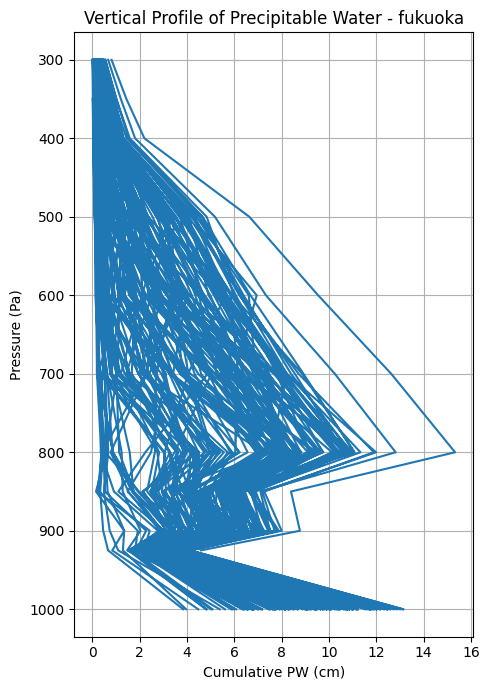

         date         PW   latitude   longitude
0  2019-06-01  15.803142  33.583333  130.383333
1  2019-06-02  41.640235  33.583333  130.383333
2  2019-06-03  27.254479  33.583333  130.383333
3  2019-06-04  37.343678  33.583333  130.383333
4  2019-06-05  27.057686  33.583333  130.383333
         date         PW  latitude   longitude
0  2019-06-01  33.014537    31.555  130.548333
1  2019-06-02  52.471765    31.555  130.548333
2  2019-06-03  47.048727    31.555  130.548333
3  2019-06-04  43.975969    31.555  130.548333
4  2019-06-05  34.552060    31.555  130.548333
         date         PW   latitude   longitude
0  2019-06-01  15.722492  35.458333  133.066667
1  2019-06-02  23.092457  35.458333  133.066667
2  2019-06-03  18.276136  35.458333  133.066667
3  2019-06-04  24.589191  35.458333  133.066667
4  2019-06-05  29.675497  35.458333  133.066667
         date         PW   latitude   longitude
0  2019-06-01  22.863331  33.451667  135.761667
1  2019-06-02  42.514957  33.451667  135.76166

In [7]:
# Radiosonde
import pandas as pd
import numpy as np
# CSV読み込み
data = pd.read_csv('radiosonde_data_20190601_to_20191101.csv') #/media/wrf/e50c04f2-f8eb-4a3f-85f1-e82d1803b4e0/hirao/radiosonde/radiosonde_data_20180101_to_20190101_siteikiatu.csv
data.replace('///', np.nan, inplace=True)
# 数値型に変換するカラム（datetime を除く）
columns_to_convert = ['気圧(hPa)', '相対湿度(%)', '気温(℃)', '風速(m/s)', '風向(°)', 'latitude', 'longitude']
for column in columns_to_convert:
    data[column] = pd.to_numeric(data[column], errors='coerce')
# datetime 列を日付時刻型に変換
data['datetime'] = pd.to_datetime(data['datetime'], errors='coerce')
# pointごとの標高辞書を作成（例）
elevation_dict = {
    47741: 3.3,     # matsue
    47778: 72.0,     # shionomisaki
    47807: 10.5,     # fukuoka
    47827: 4.0,     # kagoshima
}
data['ジオポテンシャル 高度(m)'] = data['point'].map(elevation_dict)
# ==== 期間指定 ====
start_time = pd.to_datetime('2019-06-01 00:00')
end_time   = pd.to_datetime('2019-10-31 09:00')
# ==== 期間内のデータに絞り込み ====
data_period = data[(data['datetime'] >= start_time) & (data['datetime'] <= end_time)]
# ==== 観測点ごとにフィルタリング（期間内のすべてのデータ） ====
matsue = data_period[data_period['point'] == 47741]
shionomisaki = data_period[data_period['point'] == 47778]
fukuoka = data_period[data_period['point'] == 47807]
kagoshima = data_period[data_period['point'] == 47827]
# 必要な列だけ抽出
columns_needed = ['気圧(hPa)', '相対湿度(%)', '気温(℃)', '風速(m/s)', '風向(°)',
                  'latitude', 'longitude', 'datetime', 'ジオポテンシャル 高度(m)']
matsue = matsue[columns_needed]
shionomisaki = shionomisaki[columns_needed]
fukuoka = fukuoka[columns_needed]
kagoshima = kagoshima[columns_needed]
# Add a new column for specific humidity
def calc_sh(sta_name):
    T = sta_name['気温(℃)']
    RH = sta_name['相対湿度(%)'] / 100
    P = sta_name['気圧(hPa)']  # in hPa
    # Saturation vapor pressure (Pa)
    es = 6.112 * np.exp((17.67 * T) / (T + 243.5)) * 100
    e = RH * es  # Actual vapor pressure (Pa)
    # Specific humidity (kg/kg)
    sta_name['SH'] = (0.622 * e) / (P * 100 - 0.378 * e)
    return sta_name
# Calculate SH
matsue = calc_sh(matsue)
shionomisaki = calc_sh(shionomisaki)
fukuoka = calc_sh(fukuoka)
kagoshima = calc_sh(kagoshima)
print(matsue)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
def calc_layer_pw(df):
    g = 9.80665  # 重力加速度 [m/s^2]
    result_df_list = []
    for dt, group in df.groupby('datetime'):
        group_sorted = group.sort_values('気圧(hPa)', ascending=False).copy()
        group_sorted['Pressure_Pa'] = group_sorted['気圧(hPa)'] * 100  # hPa→Pa
        # 気圧差（上の層 - 下の層）
        group_sorted['delta_p'] = group_sorted['Pressure_Pa'].diff(-1)
        # 次の層の比湿をシフトで取得
        group_sorted['SH_next'] = group_sorted['SH'].shift(-1)
        # 平均比湿を計算（上下2点の平均）
        group_sorted['avg_SH'] = (group_sorted['SH'] + group_sorted['SH_next']) / 2
        # 最下層は平均できないのでNaNになる。PW計算から除外
        group_sorted['PW'] = (group_sorted['avg_SH'] * group_sorted['delta_p']) / g
        result_df_list.append(group_sorted)
    result_df = pd.concat(result_df_list)
    return result_df
# Assuming 'wakanai' already has the 'SH' column
matsue = calc_layer_pw(matsue)
shionomisaki = calc_layer_pw(shionomisaki)
fukuoka = calc_layer_pw(fukuoka)
kagoshima = calc_layer_pw(kagoshima)
# Display the DataFrame with the new 'PW_layer' column
print(fukuoka)
plt.figure(figsize=(5, 7))
plt.plot(fukuoka['PW'], fukuoka['気圧(hPa)'])
plt.gca().invert_yaxis()
plt.xlabel('Cumulative PW (cm)')
plt.ylabel('Pressure (Pa)')
plt.title('Vertical Profile of Precipitable Water - fukuoka')
plt.grid(True)
plt.tight_layout()
plt.show()
import pandas as pd
def compute_daily_pw(df):
    # datetime列をdatetime型に変換
    df['datetime'] = pd.to_datetime(df['datetime'])
    # 日付列を作成
    df['date'] = df['datetime'].dt.date
    # 日ごとのPW合計を算出（平均や中央値に変更も可能）
    daily = df.groupby('date')['PW'].sum().reset_index()
    # 緯度・経度を抽出（代表として先頭行を使用）
    lat = df['latitude'].iloc[0]
    lon = df['longitude'].iloc[0]
    # 緯度経度列を追加
    daily['latitude'] = lat
    daily['longitude'] = lon
    return daily
# 各地点に適用
daily_kagoshima_2019 = compute_daily_pw(kagoshima)
daily_matsue_2019 = compute_daily_pw(matsue)
daily_fukuoka_2019 = compute_daily_pw(fukuoka)
daily_shionomisaki_2019 = compute_daily_pw(shionomisaki)
# 必要なら確認
print(daily_fukuoka_2019.head())
print(daily_kagoshima_2019.head())
print(daily_matsue_2019.head())
print(daily_shionomisaki_2019.head())


Total mapped 2018 PWV points: 542455 (Expected: 542455)
Total mapped 2019 PWV points: 542455 (Expected: 542455)


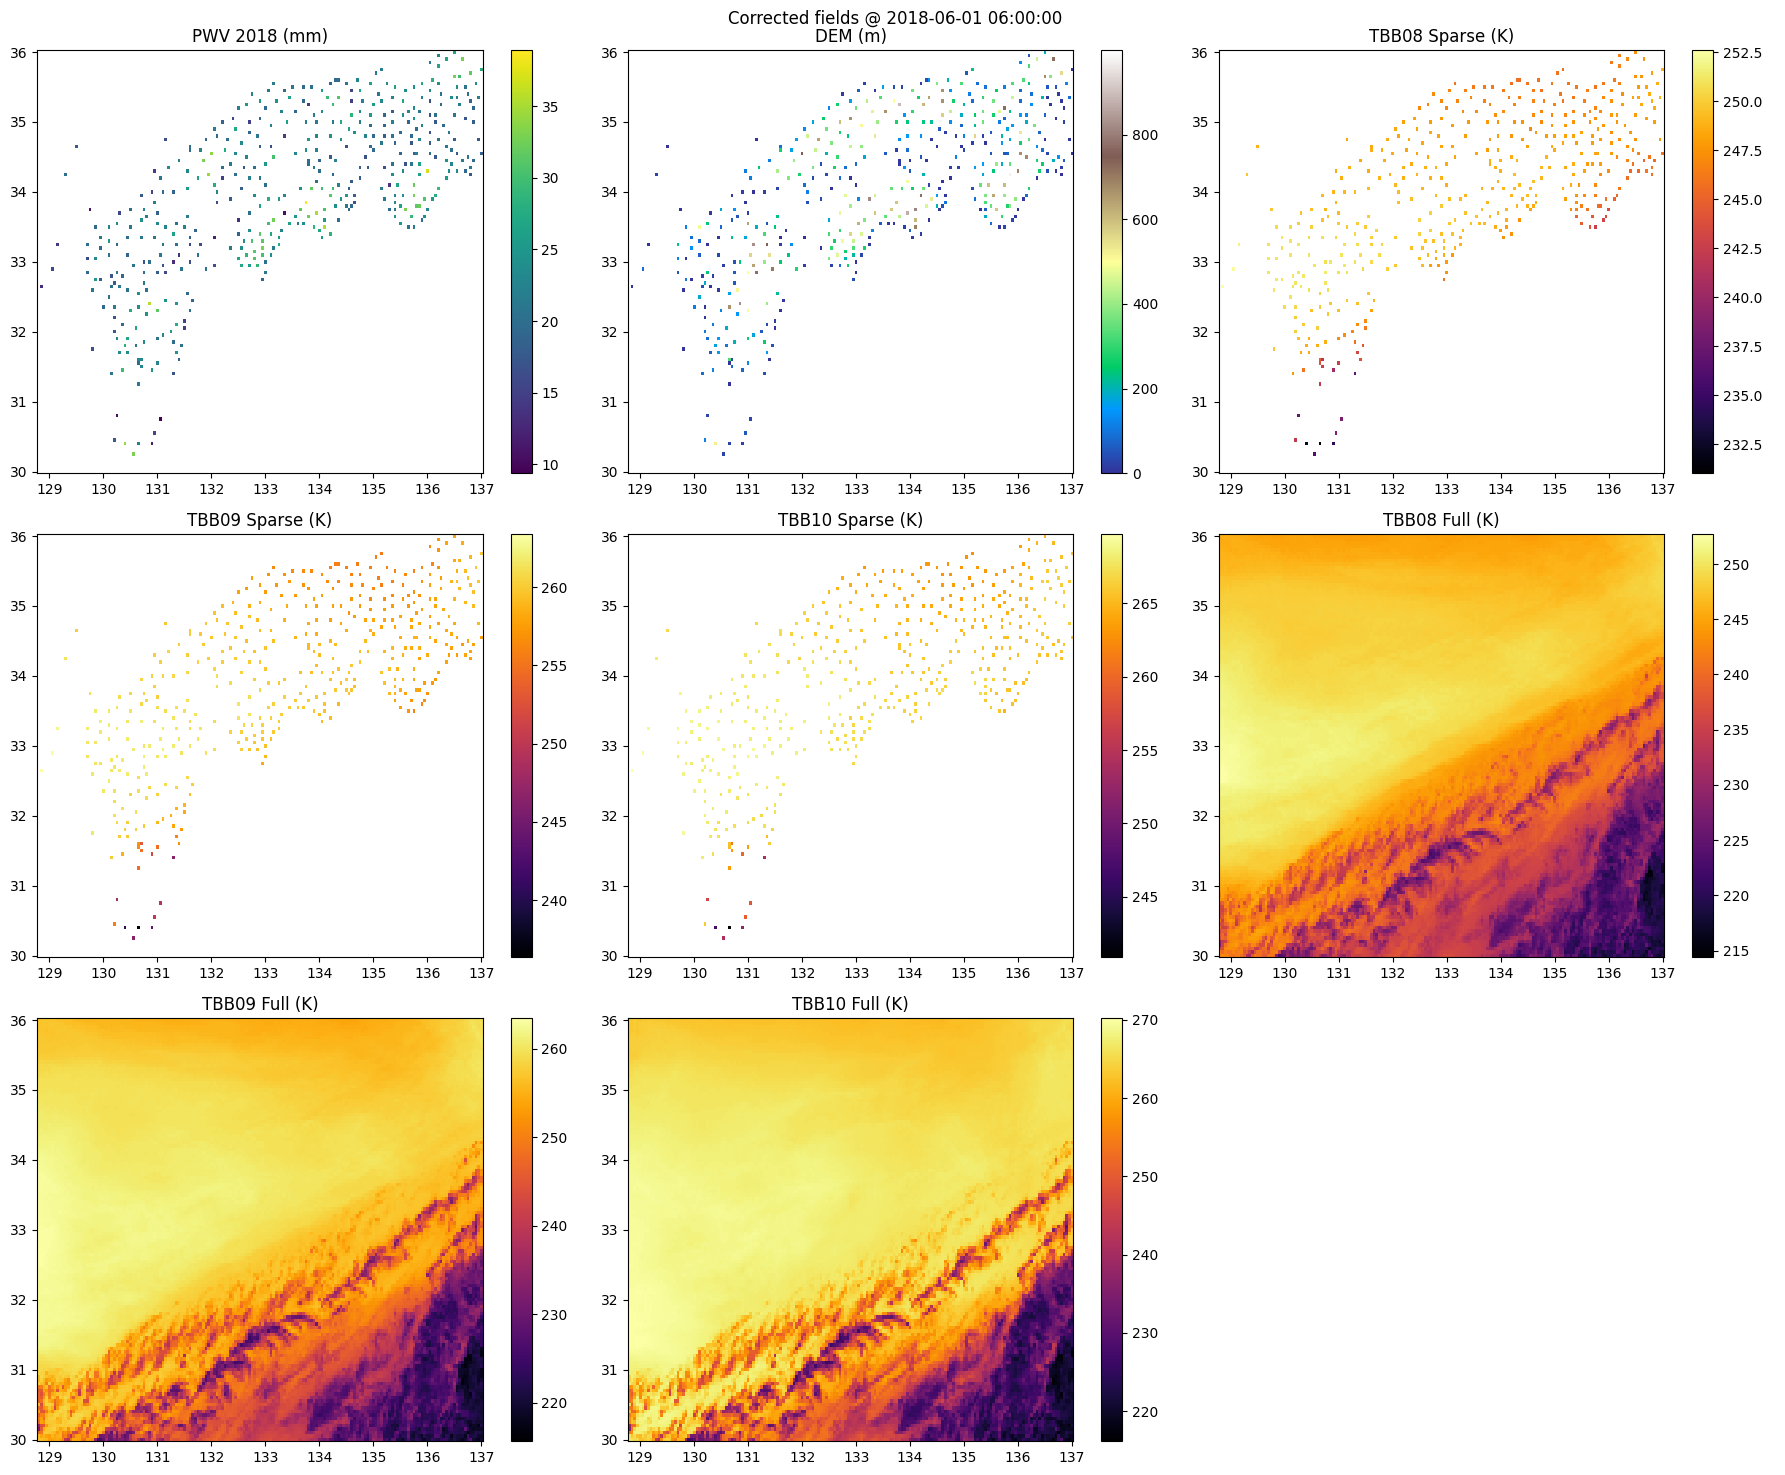

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# ============================================================
# 1. GRID INITIALIZATION (DYNAMIC 3-HOURLY TIME AXIS)
# ============================================================
times_ref = pd.to_datetime(times_ref_2018)
T = len(times_ref)
ny, nx = lat2d.shape
pwv_grid      = np.full((T, ny, nx), np.nan, dtype=np.float32)
pwv_grid_2019 = np.full((T, ny, nx), np.nan, dtype=np.float32)
# Sparse (GPS-only diagnostics)
tbb08_grid = np.full((T, ny, nx), np.nan, dtype=np.float32)
tbb09_grid = np.full((T, ny, nx), np.nan, dtype=np.float32)
tbb10_grid = np.full((T, ny, nx), np.nan, dtype=np.float32)
# FULL satellite fields at GPS times
tbb08_3h = np.full((T, ny, nx), np.nan, dtype=np.float32)
tbb09_3h = np.full((T, ny, nx), np.nan, dtype=np.float32)
tbb10_3h = np.full((T, ny, nx), np.nan, dtype=np.float32)
dem_grid_sampled = np.full((ny, nx), np.nan, dtype=np.float32)
dem_count_grid   = np.zeros((ny, nx), dtype=np.int16)
count_grid  = np.zeros((T, ny, nx), dtype=np.int16)
count_grid1 = np.zeros((T, ny, nx), dtype=np.int16)
max_dt = pd.Timedelta("5min")
# ============================================================
# 2. IMPORTANT: RAW GRID FOR INDEXING (NO FLIP EVER)
# ============================================================
lat2d_raw, lon2d_raw = np.meshgrid(lat, lon, indexing="ij")
# ============================================================
# 3. SATELLITE → 3-HOURLY TIME ALIGNMENT
# ============================================================
for t, tref in enumerate(times_ref):
    dt = np.abs(datetime_tbb - tref)
    itbb = np.argmin(dt)
    if dt[itbb] <= max_dt:
        tbb08_3h[t] = tbb08[itbb]
        tbb09_3h[t] = tbb09[itbb]
        tbb10_3h[t] = tbb10[itbb]
# ============================================================
# 4. GPS → GRID MAPPING (DIRECT MATRIX METHOD)
# ============================================================
# Connect to preprocessed variables (handles fallback variable names)
mat_2018 = pivot_2018_final if 'pivot_2018_final' in locals() else mat_2018_final
mat_2019 = pivot_2019_final if 'pivot_2019_final' in locals() else mat_2019_final
active_sites = good_sites if 'good_sites' in locals() else complete_common_stations
if 'coords_2018' in locals():
    site_coords = coords_2018
else:
    lat_c = 'lat_deg' if 'lat_deg' in GPS_2018_raw.columns else 'LAT'
    lon_c = 'lon_deg' if 'lon_deg' in GPS_2018_raw.columns else 'LON'
    site_coords = GPS_2018_raw.groupby("E_NAME")[[lat_c, lon_c]].first()
total_valid_points_2018 = 0
total_valid_points_2019 = 0
for site in active_sites:
    # Look up station coordinates
    lat_col_name = site_coords.columns[0]
    lon_col_name = site_coords.columns[1]
    lat_site = site_coords.loc[site, lat_col_name]
    lon_site = site_coords.loc[site, lon_col_name]
    # Nearest-grid lookup (RAW grid)
    dist2 = (lat2d_raw - lat_site)**2 + (lon2d_raw - lon_site)**2
    i, j = np.unravel_index(np.argmin(dist2), dist2.shape)
    # DEM accumulation
    dem_val = dem_coarse[i, j]
    if np.isfinite(dem_val):
        dem_grid_sampled[i, j] = (
            dem_val if dem_count_grid[i, j] == 0
            else dem_grid_sampled[i, j] + dem_val
        )
        dem_count_grid[i, j] += 1
    # Extract 3-hourly PWV values directly from cleaned matrices
    pwv_vals_2018 = mat_2018.loc[site].values
    pwv_vals_2019 = mat_2019.loc[site].values
    # Populate grids across all T time steps
    for t in range(T):
        # 2018 PWV
        val18 = pwv_vals_2018[t]
        if np.isfinite(val18) and val18 > 0:
            pwv_grid[t, i, j] = val18 if count_grid[t, i, j] == 0 else pwv_grid[t, i, j] + val18
            count_grid[t, i, j] += 1
            total_valid_points_2018 += 1
            # Sparse TBB diagnostics
            tbb08_grid[t, i, j] = tbb08_3h[t, i, j]
            tbb09_grid[t, i, j] = tbb09_3h[t, i, j]
            tbb10_grid[t, i, j] = tbb10_3h[t, i, j]
        # 2019 PWV
        val19 = pwv_vals_2019[t]
        if np.isfinite(val19) and val19 > 0:
            pwv_grid_2019[t, i, j] = val19 if count_grid1[t, i, j] == 0 else pwv_grid_2019[t, i, j] + val19
            count_grid1[t, i, j] += 1
            total_valid_points_2019 += 1
expected_total = len(active_sites) * T
print(f"Total mapped 2018 PWV points: {total_valid_points_2018} (Expected: {expected_total})")
print(f"Total mapped 2019 PWV points: {total_valid_points_2019} (Expected: {expected_total})")
# ============================================================
# 5. NORMALIZATION
# ============================================================
mask = count_grid > 0
pwv_grid[mask] /= count_grid[mask]
mask1 = count_grid1 > 0
pwv_grid_2019[mask1] /= count_grid1[mask1]
mask_dem = dem_count_grid > 0
dem_grid_sampled[mask_dem] /= dem_count_grid[mask_dem]
# ============================================================
# 6. PLOTTING (FLIP ONLY HERE)
# ============================================================
def plot_safe(data):
    return np.flipud(data) if flip_lat else data
t0 = 2  # Time index to visualize
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()
datasets = [
    (pwv_grid[t0],       'PWV 2018 (mm)',    'viridis'),
    (dem_grid_sampled,   'DEM (m)',          'terrain'),
    (tbb08_grid[t0],     'TBB08 Sparse (K)', 'inferno'),
    (tbb09_grid[t0],     'TBB09 Sparse (K)', 'inferno'),
    (tbb10_grid[t0],     'TBB10 Sparse (K)', 'inferno'),
    (tbb08_3h[t0],       'TBB08 Full (K)',   'inferno'),
    (tbb09_3h[t0],       'TBB09 Full (K)',   'inferno'),
    (tbb10_3h[t0],       'TBB10 Full (K)',   'inferno'),
]
for ax, (data, title, cmap) in zip(axes, datasets):
    im = ax.pcolormesh(
        lon2d, lat2d,
        plot_safe(data),
        shading="auto",
        cmap=cmap
    )
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
axes[-1].axis("off")
plt.suptitle(f"Corrected fields @ {times_ref[t0]}")
plt.tight_layout()
plt.show()

In [9]:
print(pwv_grid.shape)
print(pwv_grid_2019.shape)
import numpy as np
import numpy as np
# Create a list of the NaN masks
masks = [
    np.isnan(pwv_grid),
    np.isnan(pwv_grid_2019),
    np.isnan(tbb08_grid),
    np.isnan(tbb09_grid),
    np.isnan(tbb10_grid)
]
# Returns True only if every mask matches the first mask exactly
exact_match = all(np.array_equal(masks[0], m) for m in masks[1:])
print(f"Are filled/NaN locations identical? {exact_match}")
print(pwv_grid.shape)
print(pwv_grid_2019.shape)
# Create boolean masks where True = NaN, False = valid pixel
mask_1 = np.isnan(pwv_grid)
mask_2 = np.isnan(pwv_grid_2019)
# Count total mismatched locations
mismatches = np.sum(mask_1 != mask_2)
total_pixels = pwv_grid.size
print(f"Total grid pixels:        {total_pixels:,}")
print(f"NaNs in pwv_grid:         {mask_1.sum():,}")
print(f"NaNs in pwv_grid_2019:    {mask_2.sum():,}")
print(f"Mismatched pixel count:   {mismatches:,}")
if mismatches > 0:
    percentage = (mismatches / total_pixels) * 100
    print(f"Mismatch percentage:      {percentage:.4f}%")

(1219, 121, 165)
(1219, 121, 165)
Are filled/NaN locations identical? True
(1219, 121, 165)
(1219, 121, 165)
Total grid pixels:        24,337,335
NaNs in pwv_grid:         23,797,318
NaNs in pwv_grid_2019:    23,797,318
Mismatched pixel count:   0


Selected pixel: (i=36, j=151)  lat=34.200, lon=136.350


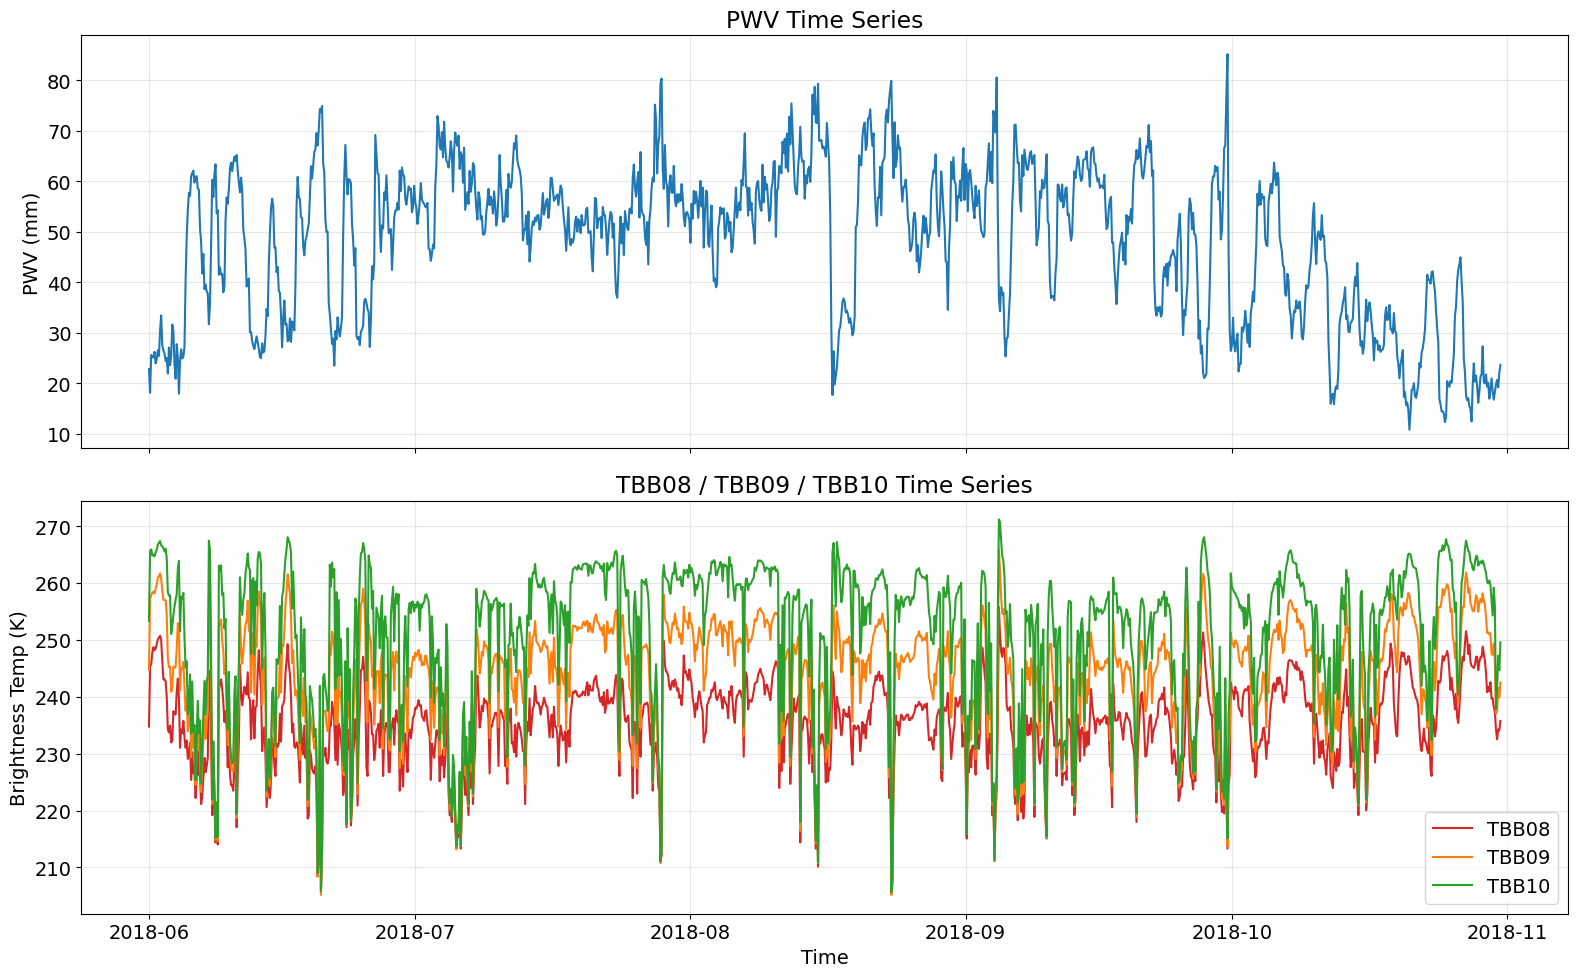

In [10]:
import matplotlib.pyplot as plt
import numpy as np
# Set global font size for all text in the plot (adjust 14 to your liking)
plt.rcParams.update({'font.size': 14})
# ------------------------------------------------------------
# 1. Select a pixel (random valid PWV pixel)
# ------------------------------------------------------------
valid_mask = np.any(~np.isnan(pwv_grid), axis=0)
valid_indices = np.argwhere(valid_mask)
i, j = valid_indices[np.random.randint(len(valid_indices))]
print(f"Selected pixel: (i={i}, j={j})  lat={lat2d_raw[i,j]:.3f}, lon={lon2d_raw[i,j]:.3f}")
# ------------------------------------------------------------
# 2. Extract time series
# ------------------------------------------------------------
pwv_ts   = pwv_grid[:, i, j]
tbb08_ts = tbb08_grid[:, i, j]
tbb09_ts = tbb09_grid[:, i, j]
tbb10_ts = tbb10_grid[:, i, j]
# ------------------------------------------------------------
# 3. Plot 2-panel figure
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
# --- Panel 1: PWV ---
axes[0].plot(times_ref_2018, pwv_ts, color="tab:blue")
axes[0].set_ylabel("PWV (mm)")
axes[0].set_title("PWV Time Series")
axes[0].grid(True, alpha=0.3)
# --- Panel 2: TBB08/09/10 in same panel ---
axes[1].plot(times_ref_2018, tbb08_ts, label="TBB08", color="tab:red")
axes[1].plot(times_ref_2018, tbb09_ts, label="TBB09", color="tab:orange")
axes[1].plot(times_ref_2018, tbb10_ts, label="TBB10", color="tab:green")
axes[1].set_ylabel("Brightness Temp (K)")
axes[1].set_title("TBB08 / TBB09 / TBB10 Time Series")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.xlabel("Time")
plt.tight_layout()
plt.show()

Selected pixel: (i=59, j=21)  lat=33.050, lon=129.850
Correlation with PWV:
  TBB08 vs PWV: r = -0.4022
  TBB09 vs PWV: r = -0.3882
  TBB10 vs PWV: r = -0.3614


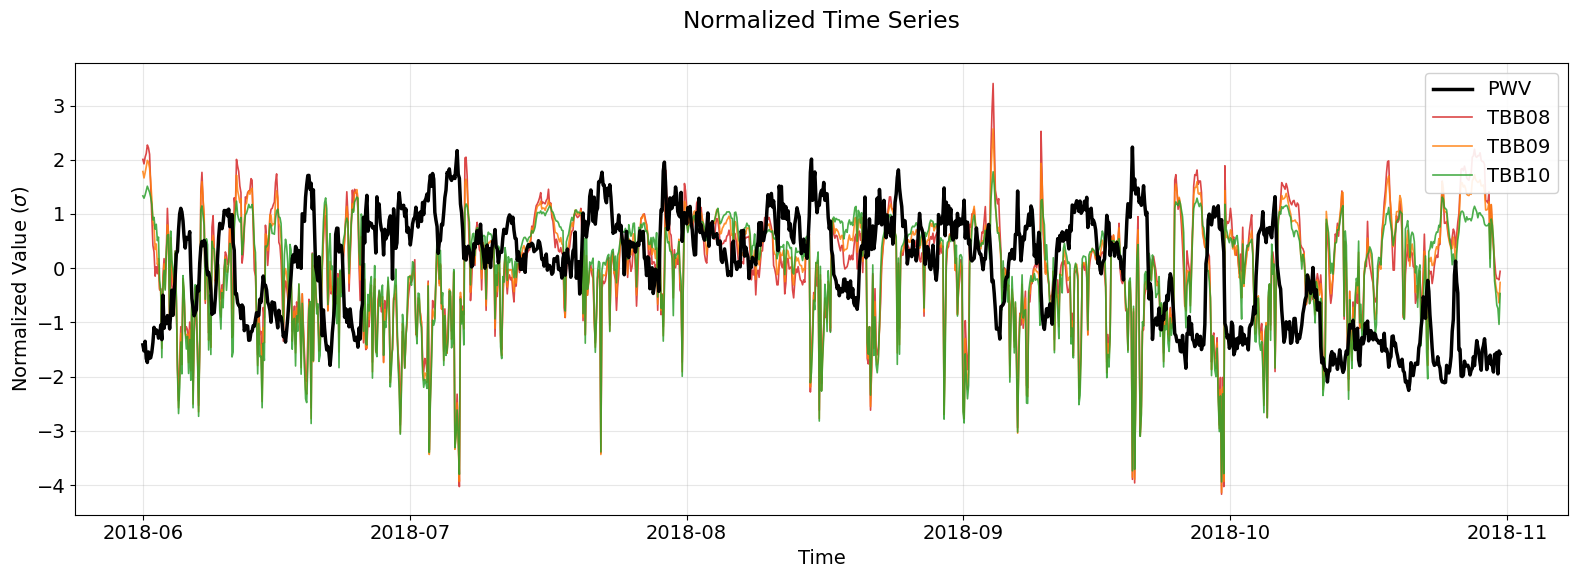

In [11]:
# Normalized Timeseries Visualization Test
import matplotlib.pyplot as plt
import numpy as np
# ------------------------------------------------------------
# 1. Select a pixel (random valid PWV pixel)
# ------------------------------------------------------------
valid_mask = np.any(~np.isnan(pwv_grid), axis=0)
valid_indices = np.argwhere(valid_mask)
i, j = valid_indices[np.random.randint(len(valid_indices))]
print(
    f"Selected pixel: (i={i}, j={j})  lat={lat2d_raw[i,j]:.3f},"
    f" lon={lon2d_raw[i,j]:.3f}"
)
# ------------------------------------------------------------
# 2. Extract time series
# ------------------------------------------------------------
pwv_ts = pwv_grid[:, i, j]
pwv_ts_2019 = pwv_grid_2019[:, i, j]
tbb08_ts = tbb08_grid[:, i, j]
tbb09_ts = tbb09_grid[:, i, j]
tbb10_ts = tbb10_grid[:, i, j]
# ------------------------------------------------------------
# 3. Mean-Std (Z-Score) Normalization
# ------------------------------------------------------------
def normalize_zscore(ts):
  return (ts - np.nanmean(ts)) / np.nanstd(ts)
pwv_norm_2019 = normalize_zscore(pwv_ts_2019)
pwv_norm = normalize_zscore(pwv_ts)
tbb08_norm = normalize_zscore(tbb08_ts)
tbb09_norm = normalize_zscore(tbb09_ts)
tbb10_norm = normalize_zscore(tbb10_ts)
# ------------------------------------------------------------
# 4. Calculate Correlation Coefficients (Handling NaNs)
# ------------------------------------------------------------
def calc_corr(a, b):
  # Keep only indices where both arrays have valid non-NaN values
  valid = ~np.isnan(a) & ~np.isnan(b)
  if np.sum(valid) < 2:
    return np.nan
  return np.corrcoef(a[valid], b[valid])[0, 1]
r_tbb08 = calc_corr(pwv_norm, tbb08_norm)
r_tbb09 = calc_corr(pwv_norm, tbb09_norm)
r_tbb10 = calc_corr(pwv_norm, tbb10_norm)
print(f"Correlation with PWV:")
print(f"  TBB08 vs PWV: r = {r_tbb08:.4f}")
print(f"  TBB09 vs PWV: r = {r_tbb09:.4f}")
print(f"  TBB10 vs PWV: r = {r_tbb10:.4f}")
# ------------------------------------------------------------
# 5. Plot single-panel normalized time series with r values
# ------------------------------------------------------------
plt.figure(figsize=(16, 6))
# Plot PWV with a thick black line
plt.plot(
    times_ref,
    pwv_norm,
    label="PWV",
    color="black",
    linewidth=2.5,
    linestyle="-",
    zorder=5,
)
# Plot Brightness Temperatures including r values in labels
plt.plot(
    times_ref,
    tbb08_norm,
    label=f"TBB08",
    color="tab:red",
    linewidth=1.2,
    alpha=0.85,
)
plt.plot(
    times_ref,
    tbb09_norm,
    label=f"TBB09",
    color="tab:orange",
    linewidth=1.2,
    alpha=0.85,
)
plt.plot(
    times_ref,
    tbb10_norm,
    label=f"TBB10",
    color="tab:green",
    linewidth=1.2,
    alpha=0.85,
)
# Formatting
plt.title(
    "Normalized Time Series\n"
)
plt.ylabel("Normalized Value ($\sigma$)")
plt.xlabel("Time")
plt.legend(loc="upper right", frameon=True, facecolor="white", framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, ConvLSTM2D, Conv2D, BatchNormalization, Lambda
)
from tensorflow.keras.models import Model
# ======================================================
# 1. TARGET NORMALIZATION
# ======================================================
T, H, W = tbb08_3h.shape
def norm_stats(x):
    return np.nanmean(x), np.nanstd(x) + 1e-6
tbb08_m, tbb08_s = norm_stats(tbb08_3h)
tbb09_m, tbb09_s = norm_stats(tbb09_3h)
tbb10_m, tbb10_s = norm_stats(tbb10_3h)
pwv_m,  pwv_s    = norm_stats(pwv_grid)
pwv_m_2019,  pwv_s_2019    = norm_stats(pwv_grid_2019)
# ======================================================
# 2. [NEW] SPATIAL HARMONIC TIME ENGINE
# ======================================================
# Assume times_ref is your pandas DatetimeIndex of length T
doy = np.array([t.timetuple().tm_yday for t in times_ref])
hod = np.array([t.hour + t.minute/60 for t in times_ref])
# Calculate 1D harmonics
doy_sin = np.sin(2 * np.pi * doy / 365.0)
doy_cos = np.cos(2 * np.pi * doy / 365.0)
hod_sin = np.sin(2 * np.pi * hod / 24.0)
hod_cos = np.cos(2 * np.pi * hod / 24.0)
# Broadcast 1D arrays to full 3D spatial grids (T, H, W)
# This explicitly tells every pixel in the map what season and time of day it is
doy_sin_grid = np.ones((T, H, W), dtype=np.float32) * doy_sin[:, None, None]
doy_cos_grid = np.ones((T, H, W), dtype=np.float32) * doy_cos[:, None, None]
hod_sin_grid = np.ones((T, H, W), dtype=np.float32) * hod_sin[:, None, None]
hod_cos_grid = np.ones((T, H, W), dtype=np.float32) * hod_cos[:, None, None]
# ======================================================
# 3. FEATURE STACKING
# ======================================================
pwv_mask = np.isfinite(pwv_grid).astype(np.float32)
pwv_fill = np.zeros_like(pwv_grid, dtype=np.float32)
# Concatenate all features (Now 10 channels instead of 6)
X = np.stack([
    (tbb08_3h - tbb08_m) / tbb08_s,
    (tbb09_3h - tbb09_m) / tbb09_s,
    (tbb10_3h - tbb10_m) / tbb10_s,
    pwv_fill,          # Sparse target placeholder
    pwv_mask,          # Data validity mask
    doy_sin_grid,      # <-- Harmonic Season Y
    doy_cos_grid,      # <-- Harmonic Season X
    hod_sin_grid,      # <-- Harmonic Diurnal Y
    hod_cos_grid       # <-- Harmonic Diurnal X
], axis=-1).astype(np.float32)
y = (pwv_grid - pwv_m) / pwv_s
y_2019 = (pwv_grid_2019 - pwv_m) / pwv_s # USE 2018 PARAMETER FOR NO CHEATING
# PWV Tendency (Auxiliary Target)
pwv_norm = y.copy()
pwv_norm_2019 = y_2019.copy()
dpwv = np.full_like(pwv_norm, np.nan, dtype=np.float32)
dpwv[1:] = pwv_norm[1:] - pwv_norm[:-1]
dpwv_2019 = np.full_like(pwv_norm_2019, np.nan, dtype=np.float32)
dpwv_2019[1:] = pwv_norm_2019[1:] - pwv_norm_2019[:-1]
# ======================================================
# 4. SEQUENCE BUILDER
# ======================================================
SEQ_LEN = 3
def make_sequences(X, y, dy, seq_len):
    Xs, ys, dys = [], [], []
    for i in range(len(X) - seq_len + 1):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len-1])
        dys.append(dy[i+seq_len-1])
    return np.array(Xs), np.array(ys), np.array(dys)
X_seq, y_seq, dy_seq = make_sequences(X, pwv_norm, dpwv, SEQ_LEN)
_, _, H, W, C = X_seq.shape  # C will now automatically be 10
X_seq_2019, y_seq_2019, dy_seq_2019 = make_sequences(X, pwv_norm_2019, dpwv_2019, SEQ_LEN)
_, _, H, W, C = X_seq.shape  # C will now automatically be 10

2026-10-01 18:10:15.106578: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-10-01 18:10:15.106619: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-10-01 18:10:15.107771: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-10-01 18:10:15.112867: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-10-01 18:10:15.808727: W tensorflow/compiler/tf2

In [13]:
# ======================================================
# 5. MODEL DEFINITION (MASKED AUTOENCODER - PCONV)
# ======================================================
import numpy as np
from sklearn.cluster import KMeans
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Input, Reshape
from tensorflow.keras import backend as K
# SPATIAL MASKING LOGIC (For Broken-to-Broken paradigm)
def get_spatial_masks(pwv_grid, dem_coarse, test_ratio=0.2, coastal_elev_thresh=50):
    station_mask = np.any(np.isfinite(pwv_grid), axis=0)
    y_idx, x_idx = np.where(station_mask)
    stations = np.column_stack((y_idx, x_idx))
    elevs = dem_coarse[y_idx, x_idx]
    elevs[np.isnan(elevs)] = 0 
    is_coastal = elevs <= coastal_elev_thresh
    is_inland = ~is_coastal
    coastal_stations = stations[is_coastal]
    inland_stations = stations[is_inland]
    def sample_uniformly(coords, ratio):
        if len(coords) == 0: return []
        n_clusters = max(1, int(len(coords) * ratio))
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit(coords)
        test_indices = []
        for center in kmeans.cluster_centers_:
            dists = np.sum((coords - center)**2, axis=1)
            test_indices.append(np.argmin(dists))
        return np.unique(test_indices)
    test_coastal_idx = sample_uniformly(coastal_stations, test_ratio)
    test_inland_idx = sample_uniformly(inland_stations, test_ratio)
    test_stations = []
    if len(test_coastal_idx) > 0:
        test_stations.extend(coastal_stations[test_coastal_idx])
    if len(test_inland_idx) > 0:
        test_stations.extend(inland_stations[test_inland_idx])
    test_stations = np.array(test_stations)
    train_mask = np.zeros(station_mask.shape, dtype=bool)
    test_mask = np.zeros(station_mask.shape, dtype=bool)
    train_mask[y_idx, x_idx] = True
    if len(test_stations) > 0:
        ty, tx = test_stations[:, 0], test_stations[:, 1]
        test_mask[ty, tx] = True
        train_mask[ty, tx] = False
    ref_sites = {
        'Fukuoka': (33.58333333, 130.3833333),
        'Kagoshima': (31.555, 130.5483333),
        'Matsue': (35.45833333, 133.0666667),
        'Shionomisaki': (33.45166667, 135.7616667),
    }
    
    for site, (lat_ref, lon_ref) in ref_sites.items():
        # Calculate distance from radiosonde to all pixels
        dist2 = (lat2d_raw - lat_ref)**2 + (lon2d_raw - lon_ref)**2
        
        # Force the distance to infinity for pixels that DON'T have a GNSS station
        dist2_gnss_only = np.where(station_mask, dist2, np.inf)
        
        # Now find the closest pixel that ACTUALLY contains a GNSS station
        ey, ex = np.unravel_index(np.argmin(dist2_gnss_only), dist2_gnss_only.shape)
        
        # Exclude exactly that GNSS pixel
        train_mask[ey, ex] = False
        test_mask[ey, ex] = False
        
    return train_mask, test_mask

train_mask_spat, test_mask_spat = get_spatial_masks(pwv_grid, dem_coarse, test_ratio=0.2)
class PConv2D(Conv2D):
    def __init__(self, *args, **kwargs):
        super(PConv2D, self).__init__(*args, **kwargs)
        self.input_spec = [tf.keras.layers.InputSpec(ndim=4), tf.keras.layers.InputSpec(ndim=4)]
    def build(self, input_shape):
        if type(input_shape) is list:
            feature_shape = input_shape[0]
        else:
            feature_shape = input_shape
        super(PConv2D, self).build(feature_shape)
        self.input_spec = [tf.keras.layers.InputSpec(ndim=4), tf.keras.layers.InputSpec(ndim=4)]
        self.mask_kernel = tf.ones((self.kernel_size[0], self.kernel_size[1], feature_shape[-1], self.filters))
        self.window_size = self.kernel_size[0] * self.kernel_size[1] * feature_shape[-1]
    def call(self, inputs, **kwargs):
        if type(inputs) is list:
            features, mask = inputs
        else:
            features = inputs
            mask = tf.ones_like(features)
        features = features * mask
        img_output = K.conv2d(
            features, self.kernel, strides=self.strides, padding=self.padding,
            data_format=self.data_format, dilation_rate=self.dilation_rate
        )
        mask_output = K.conv2d(
            mask, self.mask_kernel, strides=self.strides, padding=self.padding,
            data_format=self.data_format, dilation_rate=self.dilation_rate
        )
        mask_ratio = self.window_size / (mask_output + 1e-8)
        mask_ratio = mask_ratio * tf.cast(mask_output > 0.0, tf.float32)
        output = img_output * mask_ratio
        if self.use_bias:
            output = K.bias_add(output, self.bias, data_format=self.data_format)
        if self.activation is not None:
            output = self.activation(output)
        new_mask = tf.cast(mask_output > 0.0, tf.float32)
        new_mask = tf.clip_by_value(new_mask, 0.0, 1.0)
        return [output, new_mask]
def build_mae_pconv(seq_len, H, W):
    img_input = Input(shape=(H, W, seq_len), name="image_input")
    mask_input = Input(shape=(H, W, 1), name="mask_input")
    m = tf.tile(mask_input, [1, 1, 1, seq_len])
    # Universal Spatial Encoder with Massive Receptive Field (Dilated PConvs)
    # Dilation exponentially increases the receptive field without downsampling!
    x, m = PConv2D(64, 3, padding='same', dilation_rate=1, activation='relu')([img_input, m])
    x, m = PConv2D(64, 3, padding='same', dilation_rate=2, activation='relu')([x, m])
    x, m = PConv2D(64, 3, padding='same', dilation_rate=4, activation='relu')([x, m])
    x, m = PConv2D(64, 3, padding='same', dilation_rate=8, activation='relu')([x, m])
    x, m = PConv2D(64, 3, padding='same', dilation_rate=16, activation='relu')([x, m])
    x, m = PConv2D(64, 3, padding='same', dilation_rate=32, activation='relu')([x, m])
    # Bring it back together
    x, m = PConv2D(64, 3, padding='same', dilation_rate=1, activation='relu')([x, m])
    # Universal Spatial Decoder
    out_recon = Conv2D(seq_len, 3, padding='same', activation='linear', name='recon')(x)
    model = tf.keras.Model(inputs=[img_input, mask_input], outputs=out_recon)
    return model
print(f"\n{'='*50}\nPHASE 1: TRAINING ON BROKEN TBB -> FULL TBB\n{'='*50}")
# 1. Prepare TBB Sequences (Converting Time to Channels)
# Instead of rebuilding sequences from scratch, we use the strictly validated X_seq from Section 4.
# X_seq shape: (N, SEQ_LEN, H, W, C). The first three channels are TBB08, 09, 10.
tbb08_seq = X_seq[..., 0] # shape: (N, SEQ_LEN, H, W)
tbb09_seq = X_seq[..., 1]
tbb10_seq = X_seq[..., 2]
tbb08_seq = np.transpose(tbb08_seq, (0, 2, 3, 1)) # (N, H, W, SEQ_LEN)
tbb09_seq = np.transpose(tbb09_seq, (0, 2, 3, 1))
tbb10_seq = np.transpose(tbb10_seq, (0, 2, 3, 1))
# 2. SPATIO-TEMPORAL HOLDOUT SPLIT
np.random.seed(42)
total_times = len(tbb08_seq)
time_indices = np.arange(total_times)
np.random.shuffle(time_indices)
test_size = int(total_times * 0.15) # 15% temporal holdout
train_time_idx = time_indices[:-test_size]
test_time_idx = time_indices[-test_size:]


PHASE 1: TRAINING ON BROKEN TBB -> FULL TBB


In [14]:
STOP

NameError: name 'STOP' is not defined

In [23]:
# Save the held-out timestamps for the user
np.save("held_out_temporal_indices.npy", test_time_idx)
print(f"Total Sequences: {total_times} | Train Times: {len(train_time_idx)} | Held-Out Test Times: {len(test_time_idx)}")
# 3. Apply Split and Stack
tbb08_train = tbb08_seq[train_time_idx]
tbb09_train = tbb09_seq[train_time_idx]
tbb10_train = tbb10_seq[train_time_idx]
# Concatenate along the sample dimension (Batch)
X_train_tbb = np.concatenate([tbb08_train, tbb09_train, tbb10_train], axis=0)
# We want to predict the Full Image (Autoencoder)
Y_train_tbb = X_train_tbb
# Create the Boolean Mask for GPS stations
m_tr_tbb = np.zeros((len(X_train_tbb), 121, 165, 1), dtype=np.float32)
m_tr_tbb[:, train_mask_spat, 0] = 1.0 # Only 80% stations are visible during training
# 4. Compile and Train Model
from tensorflow.keras.callbacks import EarlyStopping
model = build_mae_pconv(SEQ_LEN, 121, 165)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='mse'
)
# Define Early Stopping with patience 5
early_stopping = EarlyStopping(
    monitor='loss',             # Monitor training loss
    patience=5,                 # Stop after 5 epochs of no improvement
    restore_best_weights=True,  # Automatically restore the best model weights
    verbose=1                   # Print a message when early stopping is triggered
)
print(f"Training on {len(X_train_tbb)} Generic Moisture Samples...")
history = model.fit(
    [X_train_tbb, m_tr_tbb], 
    Y_train_tbb,
    batch_size=8,
    epochs=50, 
    shuffle=True,
    callbacks=[early_stopping]  
)
# 5. Zero-Shot Inference on PWV
print(f"\n{'='*50}\nPHASE 2: ZERO-SHOT TRANSFER TO PWV\n{'='*50}")
print("Inferring Full PWV Grid from Broken PWV inputs...")
# We prepare the FULL timeline of PWV so downstream visualizations don't break.
y_seq_full = []
for idx in range(len(pwv_norm) - SEQ_LEN + 1):
    y_seq_full.append(pwv_norm[idx:idx+SEQ_LEN])
y_seq_full = np.array(y_seq_full)
X_test_pwv = np.transpose(y_seq_full, (0, 2, 3, 1)) # (N, H, W, SEQ_LEN)
m_test_pwv = np.zeros((len(X_test_pwv), 121, 165, 1), dtype=np.float32)
m_test_pwv[:, train_mask_spat, 0] = 1.0 
X_test_pwv_safe = np.nan_to_num(X_test_pwv, nan=0.0)
Dense_PWV = model.predict([X_test_pwv_safe, m_test_pwv], batch_size=8)
# Calculate RMSE EXCLUSIVELY on the Held-Out Test Times AND Held-Out Validation Stations!
pwv_val_target = X_test_pwv[test_time_idx][:, test_mask_spat, :]
pwv_val_pred = Dense_PWV[test_time_idx][:, test_mask_spat, :]
# Filter NaNs if any exist in the ground truth
valid_idx = ~np.isnan(pwv_val_target)
rmse = np.sqrt(np.mean((pwv_val_target[valid_idx] - pwv_val_pred[valid_idx])**2))
print(f"\nZero-Shot Spatio-Temporal RMSE (Normalized): {rmse:.4f}")
# =====================================================================
# FORMATTING FOR DOWNSTREAM VISUALIZATION CELLS
# =====================================================================
import warnings
warnings.filterwarnings('ignore', r'Mean of empty slice')

print("\nAligning predictions using Ensemble Averaged Context...")
Dense_PWV_clips_2018 = Dense_PWV * pwv_s + pwv_m

# 1. Build the 3 contexts
pwv_past = np.full_like(pwv_norm, np.nan, dtype=np.float32)
pwv_center = np.full_like(pwv_norm, np.nan, dtype=np.float32)
pwv_future = np.full_like(pwv_norm, np.nan, dtype=np.float32)

for idx in range(len(Dense_PWV_clips_2018)):
    pwv_future[idx] = Dense_PWV_clips_2018[idx, :, :, 0]
    pwv_center[idx + 1] = Dense_PWV_clips_2018[idx, :, :, 1]
    pwv_past[idx + 2] = Dense_PWV_clips_2018[idx, :, :, 2]

# 2. Calculate the Ensemble Average to use as the final baseline continuous grid!
pwv_final_continuous_grid = np.nanmean([pwv_past, pwv_center, pwv_future], axis=0)
Dense_PWV = pwv_final_continuous_grid




Total Sequences: 1217 | Train Times: 1035 | Held-Out Test Times: 182
Training on 3105 Generic Moisture Samples...
Epoch 1/50
387/389 [============================>.] - ETA: 0s - loss: 1.0458

2026-10-01 18:13:14.476096: E tensorflow/core/kernels/gpu_utils.cc:90] Detected cudnn out-of-bounds write in convolution buffer! This is likely a cudnn bug. We will skip this algorithm in the future, but your GPU state may already be corrupted, leading to incorrect results. Within Google, no action is needed on your part. Outside of Google, please ensure you're running the latest version of cudnn. If that doesn't fix the problem, please file a bug with this full error message and we'll contact nvidia.
2026-10-01 18:13:14.476133: E tensorflow/core/kernels/gpu_utils.cc:98] Redzone mismatch in LHS redzone of buffer 0x70d38ca25e00 at offset 1418560; expected ffffffffffffffff but was fffffffffdffffff.
2026-10-01 18:13:14.499526: E tensorflow/core/kernels/gpu_utils.cc:90] Detected cudnn out-of-bounds write in convolution buffer! This is likely a cudnn bug. We will skip this algorithm in the future, but your GPU state may already be corrupted, leading to incorrect results. Within Google, no a

389/389 [==============================] - 22s 52ms/step - loss: 1.0445
Epoch 2/50
389/389 [==============================] - 19s 49ms/step - loss: 0.3992
Epoch 3/50
389/389 [==============================] - 19s 50ms/step - loss: 0.3639
Epoch 4/50
389/389 [==============================] - 20s 50ms/step - loss: 0.3403
Epoch 5/50
389/389 [==============================] - 20s 50ms/step - loss: 0.3171
Epoch 6/50
389/389 [==============================] - 20s 51ms/step - loss: 0.3016
Epoch 7/50
389/389 [==============================] - 20s 51ms/step - loss: 0.2916
Epoch 8/50
389/389 [==============================] - 20s 51ms/step - loss: 0.2845
Epoch 9/50
389/389 [==============================] - 20s 50ms/step - loss: 0.2789
Epoch 10/50
389/389 [==============================] - 20s 50ms/step - loss: 0.2740
Epoch 11/50
389/389 [==============================] - 20s 50ms/step - loss: 0.2709
Epoch 12/50
389/389 [==============================] - 20s 50ms/step - loss: 0.2668
Epoch 13/50


In [ ]:
# =====================================================================
# 5. Zero-Shot Inference on PWV (2019 DATASET)
# =====================================================================
print(f"\n{'='*50}\nPHASE 2: ZERO-SHOT TRANSFER TO PWV (2019)\n{'='*50}")
print("Inferring Full PWV Grid from Broken PWV inputs for 2019...")

# We prepare the FULL timeline of PWV so downstream visualizations don't break.
y_seq_full = []
for idx in range(len(pwv_norm_2019) - SEQ_LEN + 1):
    y_seq_full.append(pwv_norm_2019[idx:idx+SEQ_LEN])
y_seq_full = np.array(y_seq_full)

X_test_pwv = np.transpose(y_seq_full, (0, 2, 3, 1)) # (N, H, W, SEQ_LEN)
m_test_pwv = np.zeros((len(X_test_pwv), 121, 165, 1), dtype=np.float32)

# Apply the Spatial Mask (Visible only at the GNSS training stations)
m_test_pwv[:, train_mask_spat, 0] = 1.0 
X_test_pwv_safe = np.nan_to_num(X_test_pwv, nan=0.0)

# Run the frozen PConvDAe model
Dense_PWV_2019 = model.predict([X_test_pwv_safe, m_test_pwv], batch_size=8)

# Calculate RMSE EXCLUSIVELY on the Held-Out Validation Stations!
# (Note: For 2019, the ENTIRE timeline is unseen by the model, so we don't subset by test_time_idx!)
pwv_val_target = X_test_pwv[:, test_mask_spat, :]
pwv_val_pred = Dense_PWV_2019[:, test_mask_spat, :]

# Filter NaNs if any exist in the ground truth
valid_idx = ~np.isnan(pwv_val_target)
rmse = np.sqrt(np.mean((pwv_val_target[valid_idx] - pwv_val_pred[valid_idx])**2))
print(f"\nZero-Shot Spatio-Temporal RMSE (2019 - Normalized): {rmse:.4f}")

# =====================================================================
# FORMATTING FOR DOWNSTREAM VISUALIZATION CELLS
# =====================================================================
import warnings
warnings.filterwarnings('ignore', r'Mean of empty slice')

print("\nAligning predictions using Ensemble Averaged Context...")
Dense_PWV_clips_2019 = Dense_PWV_2019 * pwv_s + pwv_m

# 1. Build the 3 contexts
pwv_past_19 = np.full_like(pwv_norm_2019, np.nan, dtype=np.float32)
pwv_center_19 = np.full_like(pwv_norm_2019, np.nan, dtype=np.float32)
pwv_future_19 = np.full_like(pwv_norm_2019, np.nan, dtype=np.float32)

for idx in range(len(Dense_PWV_clips_2019)):
    pwv_future_19[idx] = Dense_PWV_clips_2019[idx, :, :, 0]
    pwv_center_19[idx + 1] = Dense_PWV_clips_2019[idx, :, :, 1]
    pwv_past_19[idx + 2] = Dense_PWV_clips_2019[idx, :, :, 2]

# 2. Calculate the Ensemble Average to use as the final baseline continuous grid!
pwv_final_continuous_grid_2019 = np.nanmean([pwv_past_19, pwv_center_19, pwv_future_19], axis=0)
Dense_PWV_2019_Final = pwv_final_continuous_grid_2019




PHASE 2: ZERO-SHOT TRANSFER TO PWV (2019)
Inferring Full PWV Grid from Broken PWV inputs for 2019...
153/153 [==============================] - 3s 21ms/step

Zero-Shot Spatio-Temporal RMSE (2019 - Normalized): 0.2762

Aligning predictions using Ensemble Averaged Context...


In [ ]:
# BROKEN PC1 -> FULL PC1 MODEL
import numpy as np
import tensorflow as tf
from sklearn.decomposition import PCA

print(f"\n{'='*50}\nPHASE 1: TRAINING ON BROKEN PC1 -> FULL PC1\n{'='*50}")

# ==============================================================================
# 1. EXTRACT PC1 FROM SATELLITE TBB (USING Z-SCORE STANDARDIZATION)
# ==============================================================================
print("Fitting PCA and extracting PC1 using robust NaN masking and Z-Score...")

tbb08_raw = X_seq[..., 0] 
tbb09_raw = X_seq[..., 1]
tbb10_raw = X_seq[..., 2]
N_seq, SEQ_LEN, H, W = tbb08_raw.shape
N_total = N_seq * SEQ_LEN * H * W

tbb_stacked = np.stack([tbb08_raw.flatten(), tbb09_raw.flatten(), tbb10_raw.flatten()], axis=-1)

valid_mask_pca = ~np.isnan(tbb_stacked).any(axis=1)
tbb_valid = tbb_stacked[valid_mask_pca]

pca = PCA(n_components=1)
pcs_valid = pca.fit_transform(tbb_valid)

# ==============================================================================
# THE CRITICAL FIX: Z-SCORE STANDARDIZATION
# ==============================================================================
pc1_mean = np.mean(pcs_valid[:, 0])
pc1_std = np.std(pcs_valid[:, 0])
pc1_norm_valid = (pcs_valid[:, 0] - pc1_mean) / pc1_std

pc1_norm_flat = np.full(N_total, np.nan)
pc1_norm_flat[valid_mask_pca] = pc1_norm_valid

# Fill missing pixels with 0.0 (Since Mean = 0, this is the perfect neutral baseline!)
pc1_norm_flat = np.nan_to_num(pc1_norm_flat, nan=0.0)

# Reshape back to the 3-frame sequence format
pc1_seq = pc1_norm_flat.reshape((N_seq, SEQ_LEN, H, W))
pc1_seq = np.transpose(pc1_seq, (0, 2, 3, 1)) # Final Shape: (N, H, W, SEQ_LEN)


# ==============================================================================
# 2. SPATIO-TEMPORAL HOLDOUT SPLIT
# ==============================================================================
np.random.seed(42)
time_indices = np.arange(N_seq)
np.random.shuffle(time_indices)
test_size = int(N_seq * 0.15) # 15% temporal holdout
train_time_idx = time_indices[:-test_size]
test_time_idx = time_indices[-test_size:]

# Save the held-out timestamps for downstream use
np.save("held_out_temporal_indices.npy", test_time_idx)
print(f"Total Sequences: {N_seq} | Train Times: {len(train_time_idx)} | Held-Out Test Times: {len(test_time_idx)}")

# Apply Split: We now only have ONE feature (PC1)
X_train_pc1 = pc1_seq[train_time_idx]
Y_train_pc1 = X_train_pc1  # Autoencoder target is to reconstruct itself

# Create the Boolean Mask for GPS stations (simulating broken data)
m_tr_pc1 = np.zeros((len(X_train_pc1), 121, 165, 1), dtype=np.float32)
m_tr_pc1[:, train_mask_spat, 0] = 1.0 

# ==============================================================================
# 3. COMPILE AND TRAIN (PC1 AUTOENCODER)
# ==============================================================================
from tensorflow.keras.callbacks import EarlyStopping
model = build_mae_pconv(SEQ_LEN, 121, 165)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='mse'
)
# Define Early Stopping with patience 5
early_stopping = EarlyStopping(
    monitor='loss',             # Monitor training loss
    patience=5,                 # Stop after 5 epochs of no improvement
    restore_best_weights=True,  # Automatically restore the best model weights
    verbose=1                   # Print a message when early stopping is triggered
)
print(f"Training on {len(X_train_tbb)} Generic Moisture Samples...")
history = model.fit(
    [X_train_tbb, m_tr_tbb], 
    Y_train_tbb,
    batch_size=8,
    epochs=50, 
    shuffle=True,
    callbacks=[early_stopping]  # <--- Pass the callback here
)
# ==============================================================================
# PHASE 2: ZERO-SHOT TRANSFER TO PWV (FROZEN WEIGHTS)
# ==============================================================================
print(f"\n{'='*50}\nPHASE 2: ZERO-SHOT TRANSFER TO PWV\n{'='*50}")
print("Inferring Full PWV Grid using Frozen PC1 Weights...")

# We prepare the FULL timeline of PWV
y_seq_full = []
for idx in range(len(pwv_norm) - SEQ_LEN + 1):
    y_seq_full.append(pwv_norm[idx:idx+SEQ_LEN])
y_seq_full = np.array(y_seq_full)

X_test_pwv = np.transpose(y_seq_full, (0, 2, 3, 1)) # (N, H, W, SEQ_LEN)
m_test_pwv = np.zeros((len(X_test_pwv), 121, 165, 1), dtype=np.float32)
m_test_pwv[:, train_mask_spat, 0] = 1.0 

X_test_pwv_safe = np.nan_to_num(X_test_pwv, nan=0.0)

# ------------------------------------------------------------------------------
# ZERO-SHOT INFERENCE (The model is completely frozen here, no fine-tuning)
# ------------------------------------------------------------------------------
Dense_PWV = model.predict([X_test_pwv_safe, m_test_pwv], batch_size=8)

# Calculate RMSE EXCLUSIVELY on the Held-Out Test Times AND Held-Out Validation Stations
pwv_val_target = X_test_pwv[test_time_idx][:, test_mask_spat, :]
pwv_val_pred = Dense_PWV[test_time_idx][:, test_mask_spat, :]

# Filter NaNs if any exist in the ground truth
valid_idx = ~np.isnan(pwv_val_target)
rmse = np.sqrt(np.mean((pwv_val_target[valid_idx] - pwv_val_pred[valid_idx])**2))

print(f"\nZero-Shot Spatio-Temporal RMSE (Normalized): {rmse:.4f}")



PHASE 1: TRAINING ON BROKEN PC1 -> FULL PC1
Fitting PCA and extracting PC1 using robust NaN masking and Z-Score...
Total Sequences: 1217 | Train Times: 1035 | Held-Out Test Times: 182
Training on 3105 Generic Moisture Samples...
Epoch 1/50
389/389 [==============================] - 22s 49ms/step - loss: 0.8731
Epoch 2/50
389/389 [==============================] - 19s 49ms/step - loss: 0.3789
Epoch 3/50
389/389 [==============================] - 19s 50ms/step - loss: 0.3532
Epoch 4/50
389/389 [==============================] - 19s 50ms/step - loss: 0.3405
Epoch 5/50
389/389 [==============================] - 19s 50ms/step - loss: 0.3223
Epoch 6/50
389/389 [==============================] - 19s 50ms/step - loss: 0.2994
Epoch 7/50
389/389 [==============================] - 20s 50ms/step - loss: 0.2864
Epoch 8/50
389/389 [==============================] - 20s 50ms/step - loss: 0.2790
Epoch 9/50
389/389 [==============================] - 20s 50ms/step - loss: 0.2737
Epoch 10/50
389/389 [==

In [44]:
# =====================================================================
# PHASE 2: ZERO-SHOT TRANSFER TO PWV (2019 DATASET)
# Using the Frozen PC1-Trained Autoencoder
# =====================================================================
print(f"\n{'='*50}\nPHASE 2: ZERO-SHOT TRANSFER TO PWV (2019)\n{'='*50}")
print("Inferring Full PWV Grid from Broken PWV inputs for 2019 using frozen PC1 weights...")

# 1. Prepare the FULL timeline of PWV from the unseen 2019 dataset
y_seq_full_2019 = []
for idx in range(len(pwv_norm_2019) - SEQ_LEN + 1):
    y_seq_full_2019.append(pwv_norm_2019[idx:idx+SEQ_LEN])
y_seq_full_2019 = np.array(y_seq_full_2019)

X_test_pwv_2019 = np.transpose(y_seq_full_2019, (0, 2, 3, 1)) # (N, H, W, SEQ_LEN)
m_test_pwv_2019 = np.zeros((len(X_test_pwv_2019), 121, 165, 1), dtype=np.float32)

# 2. Apply the Spatial Mask (Visible only at the GNSS training stations)
m_test_pwv_2019[:, train_mask_spat, 0] = 1.0 
X_test_pwv_safe_2019 = np.nan_to_num(X_test_pwv_2019, nan=0.0)

# 3. ZERO-SHOT INFERENCE
Dense_PWV_2019_PC1 = model.predict([X_test_pwv_safe_2019, m_test_pwv_2019], batch_size=8)

# 4. EVALUATION
pwv_val_target_2019 = X_test_pwv_2019[:, test_mask_spat, :]
pwv_val_pred_2019_PC1 = Dense_PWV_2019_PC1[:, test_mask_spat, :]

valid_idx_2019 = ~np.isnan(pwv_val_target_2019)
rmse_2019_pc1 = np.sqrt(np.mean((pwv_val_target_2019[valid_idx_2019] - pwv_val_pred_2019_PC1[valid_idx_2019])**2))
print(f"\nZero-Shot Spatio-Temporal RMSE (2019 - Normalized): {rmse_2019_pc1:.4f}")

# =====================================================================
# 5. ENSEMBLE AVERAGING AND DENORMALIZATION
# =====================================================================
import warnings
warnings.filterwarnings('ignore', r'Mean of empty slice')

print("\nAligning predictions using Ensemble Averaged Context...")

# Denormalize back to real physical PWV values (mm) using your stored scalars
Dense_PWV_clips_2019_PC1 = Dense_PWV_2019_PC1 * pwv_s + pwv_m

# Build the 3 contexts
pwv_past_19_pc1 = np.full_like(pwv_norm_2019, np.nan, dtype=np.float32)
pwv_center_19_pc1 = np.full_like(pwv_norm_2019, np.nan, dtype=np.float32)
pwv_future_19_pc1 = np.full_like(pwv_norm_2019, np.nan, dtype=np.float32)

for idx in range(len(Dense_PWV_clips_2019_PC1)):
    pwv_future_19_pc1[idx]   = Dense_PWV_clips_2019_PC1[idx, :, :, 0]
    pwv_center_19_pc1[idx+1] = Dense_PWV_clips_2019_PC1[idx, :, :, 1]
    pwv_past_19_pc1[idx+2]   = Dense_PWV_clips_2019_PC1[idx, :, :, 2]

# Calculate the Ensemble Average to use as the final baseline continuous grid!
pwv_final_continuous_grid_2019_PC1 = np.nanmean([pwv_past_19_pc1, pwv_center_19_pc1, pwv_future_19_pc1], axis=0)

print("Ensemble Averaging Complete!")
print(f"Final shape of the new PC1 grid: {pwv_final_continuous_grid_2019_PC1.shape}")



PHASE 2: ZERO-SHOT TRANSFER TO PWV (2019)
Inferring Full PWV Grid from Broken PWV inputs for 2019 using frozen PC1 weights...
153/153 [==============================] - 3s 21ms/step

Zero-Shot Spatio-Temporal RMSE (2019 - Normalized): 0.2811

Aligning predictions using Ensemble Averaged Context...
Ensemble Averaging Complete!
Final shape of the new PC1 grid: (1219, 121, 165)


In [ ]:
# =====================================================================
# OVERLAP TEST: t1 and t2 difference between Clip 1 and Clip 2
# =====================================================================
import numpy as np

print("Testing difference between overlapping frames in sequential clips (2018)...")

# Clip 1 (index 0) frames: t0, t1, t2 -> index 0, 1, 2
# Clip 2 (index 1) frames: t1, t2, t3 -> index 0, 1, 2

# Extract t1 from Clip 1 (index 1) and Clip 2 (index 0)
t1_clip1 = Dense_PWV_clips_2018[0, :, :, 1]
t1_clip2 = Dense_PWV_clips_2018[1, :, :, 0]
diff_t1 = np.abs(t1_clip1 - t1_clip2)

# Extract t2 from Clip 1 (index 2) and Clip 2 (index 1)
t2_clip1 = Dense_PWV_clips_2018[0, :, :, 2]
t2_clip2 = Dense_PWV_clips_2018[1, :, :, 1]
diff_t2 = np.abs(t2_clip1 - t2_clip2)

print(f"Mean Absolute Difference for t1 (Clip 1 vs Clip 2): {np.nanmean(diff_t1):.4f} mm")
print(f"Max Absolute Difference for t1 (Clip 1 vs Clip 2): {np.nanmax(diff_t1):.4f} mm")
print("-" * 50)
print(f"Mean Absolute Difference for t2 (Clip 1 vs Clip 2): {np.nanmean(diff_t2):.4f} mm")
print(f"Max Absolute Difference for t2 (Clip 1 vs Clip 2): {np.nanmax(diff_t2):.4f} mm")



Testing difference between overlapping frames in sequential clips (2018)...
Mean Absolute Difference for t1 (Clip 1 vs Clip 2): 2.0748 mm
Max Absolute Difference for t1 (Clip 1 vs Clip 2): 16.2794 mm
--------------------------------------------------
Mean Absolute Difference for t2 (Clip 1 vs Clip 2): 2.4831 mm
Max Absolute Difference for t2 (Clip 1 vs Clip 2): 16.1837 mm


In [ ]:
# =====================================================================
# OVERLAP TEST (2019 DATASET)
# =====================================================================
print("Testing difference between overlapping frames in sequential clips (2019)...")

# Extract t1 from Clip 1 (index 1) and Clip 2 (index 0)
t1_clip1_2019 = Dense_PWV_clips_2019[0, :, :, 1]
t1_clip2_2019 = Dense_PWV_clips_2019[1, :, :, 0]
diff_t1_2019 = np.abs(t1_clip1_2019 - t1_clip2_2019)

# Extract t2 from Clip 1 (index 2) and Clip 2 (index 1)
t2_clip1_2019 = Dense_PWV_clips_2019[0, :, :, 2]
t2_clip2_2019 = Dense_PWV_clips_2019[1, :, :, 1]
diff_t2_2019 = np.abs(t2_clip1_2019 - t2_clip2_2019)

print(f"Mean Absolute Difference for t1 (Clip 1 vs Clip 2): {np.nanmean(diff_t1_2019):.4f} mm")
print(f"Max Absolute Difference for t1 (Clip 1 vs Clip 2): {np.nanmax(diff_t1_2019):.4f} mm")
print("-" * 50)
print(f"Mean Absolute Difference for t2 (Clip 1 vs Clip 2): {np.nanmean(diff_t2_2019):.4f} mm")
print(f"Max Absolute Difference for t2 (Clip 1 vs Clip 2): {np.nanmax(diff_t2_2019):.4f} mm")


Testing difference between overlapping frames in sequential clips (2019)...
Mean Absolute Difference for t1 (Clip 1 vs Clip 2): 1.7701 mm
Max Absolute Difference for t1 (Clip 1 vs Clip 2): 15.5416 mm
--------------------------------------------------
Mean Absolute Difference for t2 (Clip 1 vs Clip 2): 1.9919 mm
Max Absolute Difference for t2 (Clip 1 vs Clip 2): 14.4582 mm


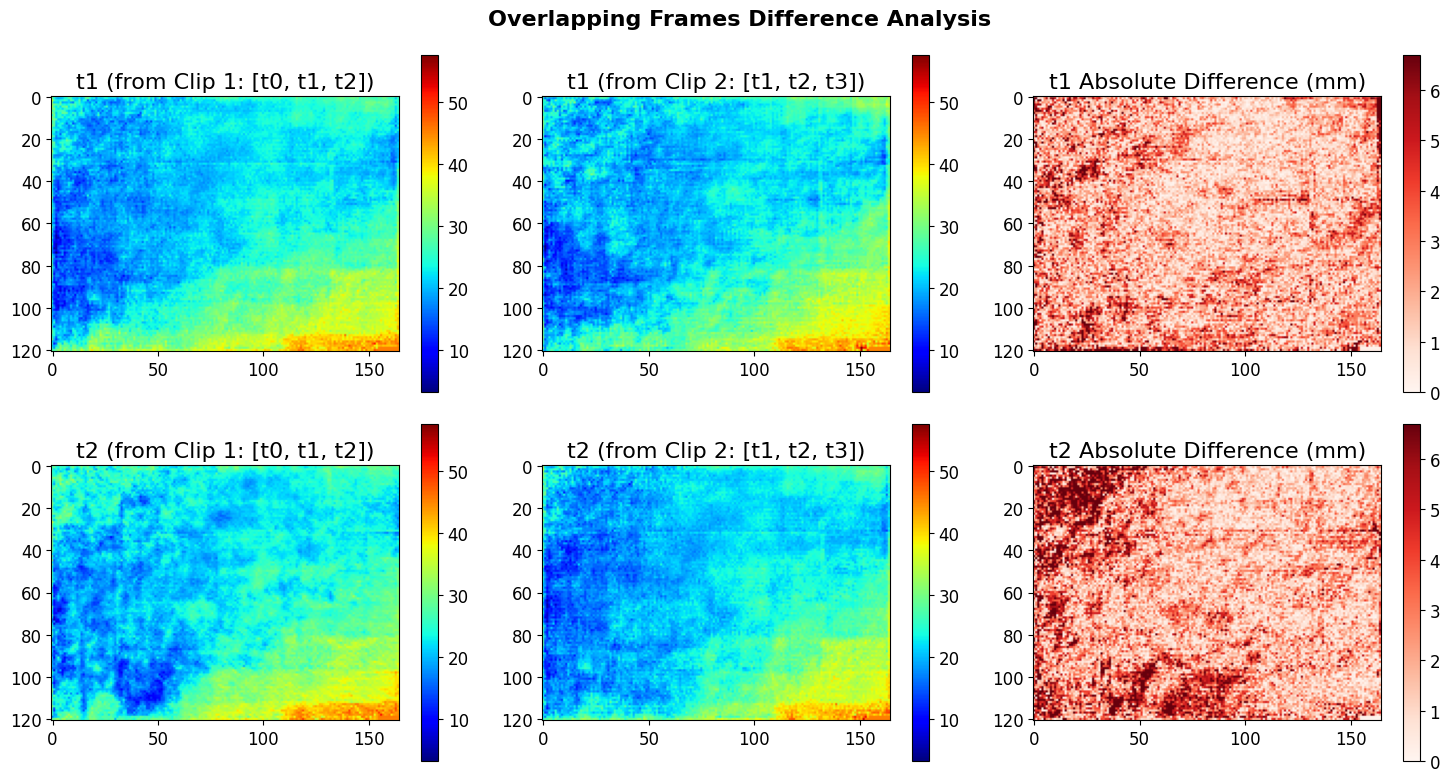

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Find global min and max to ensure colorbars are perfectly identical for visual comparison
vmin_pwv = np.nanmin([t1_clip1, t1_clip2, t2_clip1, t2_clip2])
vmax_pwv = np.nanmax([t1_clip1, t1_clip2, t2_clip1, t2_clip2])

# Find a global max for the error difference plots
vmax_diff = np.nanmax([np.nanpercentile(diff_t1, 95), np.nanpercentile(diff_t2, 95)])
if np.isnan(vmax_diff): vmax_diff = 2.0

# ==========================================
# ROW 1: t1 Plot (Clip 1 vs Clip 2)
# ==========================================
im1 = axes[0,0].imshow(t1_clip1, cmap='jet', vmin=vmin_pwv, vmax=vmax_pwv)
axes[0,0].set_title("t1 (from Clip 1: [t0, t1, t2])")
fig.colorbar(im1, ax=axes[0,0])

im2 = axes[0,1].imshow(t1_clip2, cmap='jet', vmin=vmin_pwv, vmax=vmax_pwv)
axes[0,1].set_title("t1 (from Clip 2: [t1, t2, t3])")
fig.colorbar(im2, ax=axes[0,1])

im3 = axes[0,2].imshow(diff_t1, cmap='Reds', vmin=0, vmax=vmax_diff)
axes[0,2].set_title("t1 Absolute Difference (mm)")
fig.colorbar(im3, ax=axes[0,2])

# ==========================================
# ROW 2: t2 Plot (Clip 1 vs Clip 2)
# ==========================================
im4 = axes[1,0].imshow(t2_clip1, cmap='jet', vmin=vmin_pwv, vmax=vmax_pwv)
axes[1,0].set_title("t2 (from Clip 1: [t0, t1, t2])")
fig.colorbar(im4, ax=axes[1,0])

im5 = axes[1,1].imshow(t2_clip2, cmap='jet', vmin=vmin_pwv, vmax=vmax_pwv)
axes[1,1].set_title("t2 (from Clip 2: [t1, t2, t3])")
fig.colorbar(im5, ax=axes[1,1])

im6 = axes[1,2].imshow(diff_t2, cmap='Reds', vmin=0, vmax=vmax_diff)
axes[1,2].set_title("t2 Absolute Difference (mm)")
fig.colorbar(im6, ax=axes[1,2])

plt.suptitle("Overlapping Frames Difference Analysis", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# =====================================================================
# RANDOM FOREST BASELINE (Zero-Shot Tabular Transfer)
# =====================================================================
from sklearn.ensemble import RandomForestRegressor
from scipy.spatial import cKDTree
import numpy as np
import time
print("Preparing Random Forest baseline...")
# 1. Build spatial tree for the valid training anchor stations
# train_mask_spat is True for the 80% GPS stations
y_train_idx, x_train_idx = np.where(train_mask_spat)
train_coords = np.column_stack((y_train_idx, x_train_idx))
tree = cKDTree(train_coords)
# 2. Extract features for a random subset of TBB pixels to train the RF
print("Extracting TBB training features...")
np.random.seed(42)
# Sample 100,000 random pixels across all times and locations to train RF
N_train_samples = 100000 
t_idx = np.random.randint(0, len(X_train_tbb), N_train_samples)
y_idx = np.random.randint(0, 121, N_train_samples)
x_idx = np.random.randint(0, 165, N_train_samples)
target_coords = np.column_stack((y_idx, x_idx))
# Find the K=4 nearest GPS stations for each target pixel
K = 4
distances, indices = tree.query(target_coords, k=K)
# Build Tabular Training Data (X_rf, Y_rf)
# X_rf features: Lat, Lon, Dists (4), Values at anchor stations (4 x SEQ_LEN)
# Y_rf target: Actual TBB value at target pixel
X_rf = []
Y_rf = []
for i in range(N_train_samples):
    t = t_idx[i]
    cy = y_idx[i]
    cx = x_idx[i]
    feat = [cy, cx]
    feat.extend(distances[i])
    for k in range(K):
        anchor_idx = indices[i, k]
        ay, ax = train_coords[anchor_idx]
        feat.extend(X_train_tbb[t, ay, ax, :])
    X_rf.append(feat)
    Y_rf.append(X_train_tbb[t, cy, cx, SEQ_LEN-1])
X_rf = np.array(X_rf)
Y_rf = np.array(Y_rf)
# Drop any NaNs
valid = ~np.isnan(Y_rf)
X_rf = X_rf[valid]
Y_rf = Y_rf[valid]
print("Training Random Forest...")
start_time = time.time()
rf_model = RandomForestRegressor(n_estimators=50, max_depth=15, n_jobs=-1, random_state=42)
rf_model.fit(X_rf, Y_rf)
print(f"RF Training took {time.time() - start_time:.2f} seconds.")
# =====================================================================
# ZERO-SHOT INFERENCE ON PWV (2019)
# =====================================================================
print("Extracting PWV test features for RF Zero-Shot Inference (2019)...")
# We predict the held-out test stations for RMSE calculation!
y_test_idx, x_test_idx = np.where(test_mask_spat)
test_coords = np.column_stack((y_test_idx, x_test_idx))
test_distances, test_indices = tree.query(test_coords, k=K)
X_rf_test = []
Y_rf_test = []
for t in range(len(X_test_pwv)):
    for i in range(len(test_coords)):
        cy, cx = test_coords[i]
        feat = [cy, cx]
        feat.extend(test_distances[i])
        for k in range(K):
            anchor_idx = test_indices[i, k]
            ay, ax = train_coords[anchor_idx]
            vals = X_test_pwv[t, ay, ax, :]
            feat.extend(np.nan_to_num(vals, nan=0.0))
        X_rf_test.append(feat)
        Y_rf_test.append(X_test_pwv[t, cy, cx, SEQ_LEN-1])
X_rf_test = np.array(X_rf_test)
Y_rf_test = np.array(Y_rf_test)
valid_test = ~np.isnan(Y_rf_test)
X_rf_test = X_rf_test[valid_test]
Y_rf_test = Y_rf_test[valid_test]
print("Predicting with Random Forest...")
Y_rf_pred = rf_model.predict(X_rf_test)
rmse_rf = np.sqrt(np.mean((Y_rf_test - Y_rf_pred)**2))
print(f"\nRandom Forest Zero-Shot RMSE (2019 - Normalized): {rmse_rf:.4f}")


# =====================================================================
# FULL GRID RECONSTRUCTION (2018 & 2019)
# =====================================================================
print("\nGenerating FULL grid reconstruction for 2018 & 2019 using RF...")

all_y, all_x = np.indices((121, 165))
grid_coords = np.column_stack((all_y.flatten(), all_x.flatten()))
grid_distances, grid_indices = tree.query(grid_coords, k=K)

def reconstruct_full_grid_rf(X_input_seq, distances, indices):
    N_time = len(X_input_seq)
    N_pixels = len(grid_coords)
    
    ay = train_coords[indices][:, :, 0]
    ax = train_coords[indices][:, :, 1]
    
    Y_pred_full = np.zeros((N_time, N_pixels), dtype=np.float32)
    static_feat = np.column_stack((grid_coords[:, 0], grid_coords[:, 1], distances))
    
    print(f"Reconstructing {N_time} time steps...")
    for t in range(N_time):
        if t % 100 == 0:
            print(f"Step {t}/{N_time}")
        vals = X_input_seq[t, ay, ax, :]
        vals = np.nan_to_num(vals, nan=0.0).reshape(N_pixels, K * SEQ_LEN)
        
        X_rf_grid = np.hstack((static_feat, vals))
        Y_pred_full[t] = rf_model.predict(X_rf_grid)
        
    return Y_pred_full.reshape(N_time, 121, 165)

# Rebuild 2018 sequence because X_test_pwv was overwritten by 2019 in earlier cells
y_seq_full_2018 = []
for idx in range(len(pwv_norm) - SEQ_LEN + 1):
    y_seq_full_2018.append(pwv_norm[idx:idx+SEQ_LEN])
X_test_pwv_2018 = np.transpose(np.array(y_seq_full_2018), (0, 2, 3, 1))

# Perform the fast vectorized reconstruction
pwv_recon_rf_2018 = reconstruct_full_grid_rf(X_test_pwv_2018, grid_distances, grid_indices)
pwv_recon_rf_2019 = reconstruct_full_grid_rf(X_test_pwv, grid_distances, grid_indices)

# Align to original timeline and un-scale
pwv_aligned_rf_2018 = np.full_like(pwv_norm, np.nan, dtype=np.float32)
for idx in range(len(X_test_pwv_2018)):
    pwv_aligned_rf_2018[idx + SEQ_LEN - 1] = pwv_recon_rf_2018[idx]
pwv_final_rf_2018 = pwv_aligned_rf_2018 * pwv_s + pwv_m

pwv_aligned_rf_2019 = np.full_like(pwv_norm_2019, np.nan, dtype=np.float32)
for idx in range(len(X_test_pwv)):
    pwv_aligned_rf_2019[idx + SEQ_LEN - 1] = pwv_recon_rf_2019[idx]
pwv_final_rf_2019 = pwv_aligned_rf_2019 * pwv_s + pwv_m

print("RF Full Grid Reconstruction Complete! Variables ready: pwv_final_rf_2018, pwv_final_rf_2019")



Preparing Random Forest baseline...
Extracting TBB training features...


Training Random Forest...
RF Training took 1.66 seconds.
Extracting PWV test features for RF Zero-Shot Inference (2019)...
Predicting with Random Forest...

Random Forest Zero-Shot RMSE (2019 - Normalized): 0.3165

Generating FULL grid reconstruction for 2018 & 2019 using RF...
Reconstructing 1217 time steps...
Step 0/1217
Step 100/1217
Step 200/1217
Step 300/1217
Step 400/1217
Step 500/1217
Step 600/1217
Step 700/1217
Step 800/1217
Step 900/1217
Step 1000/1217
Step 1100/1217
Step 1200/1217
Reconstructing 1217 time steps...
Step 0/1217
Step 100/1217
Step 200/1217
Step 300/1217
Step 400/1217
Step 500/1217
Step 600/1217
Step 700/1217
Step 800/1217
Step 900/1217
Step 1000/1217
Step 1100/1217
Step 1200/1217
RF Full Grid Reconstruction Complete! Variables ready: pwv_final_rf_2018, pwv_final_rf_2019


In [ ]:
# =====================================================================
# IDW & KRIGING BASELINES (Mathematical Spatial Interpolation)
# =====================================================================
import numpy as np
from scipy.spatial import cKDTree
import time
try:
    from pykrige.ok import OrdinaryKriging
    has_pykrige = True
except ImportError:
    has_pykrige = False
    print("WARNING: pykrige is not installed. Kriging will be skipped. Run '!pip install pykrige'")

print("Preparing IDW and Kriging baselines...")

# Anchor stations (80% GPS stations)
y_train_idx, x_train_idx = np.where(train_mask_spat)
train_coords = np.column_stack((y_train_idx, x_train_idx))

# Test stations (20% GPS stations) for RMSE
y_test_idx, x_test_idx = np.where(test_mask_spat)

# All Grid coords for full reconstruction
all_y, all_x = np.indices((121, 165))
grid_coords = np.column_stack((all_y.flatten(), all_x.flatten()))

# -------------------------------------------------------------
# 1. FAST VECTORIZED IDW IMPLEMENTATION
# -------------------------------------------------------------
def run_idw(input_sparse_grid, power=2, k_neighbors=8):
    N_time = len(input_sparse_grid)
    N_pixels = len(grid_coords)
    
    Y_pred_full = np.zeros((N_time, N_pixels), dtype=np.float32)
    tree = cKDTree(train_coords)
    
    dists, indices = tree.query(grid_coords, k=k_neighbors)
    dists = np.where(dists == 0, 1e-10, dists)
    weights = 1.0 / (dists ** power)
    weight_sums = np.sum(weights, axis=1)
    
    ay = train_coords[indices][:, :, 0]
    ax = train_coords[indices][:, :, 1]
    
    print(f"Running IDW for {N_time} time steps...")
    for t in range(N_time):
        vals = input_sparse_grid[t, ay, ax] 
        vals = np.nan_to_num(vals, nan=0.0)
        weighted_vals = np.sum(vals * weights, axis=1) / weight_sums
        Y_pred_full[t] = weighted_vals
        
    return Y_pred_full.reshape(N_time, 121, 165)

print("\n--- Running IDW (2018) ---")
# Use the raw unscaled PWV grid for mathematical interpolation
pwv_final_idw_2018 = run_idw(pwv_grid)
idw_val_pred_2018 = pwv_final_idw_2018[:, y_test_idx, x_test_idx]
pwv_val_target_2018 = pwv_grid[:, y_test_idx, x_test_idx]
valid_idx = ~np.isnan(pwv_val_target_2018)
rmse_idw_2018 = np.sqrt(np.mean((pwv_val_target_2018[valid_idx] - idw_val_pred_2018[valid_idx])**2))
print(f"IDW RMSE (2018 - Raw units): {rmse_idw_2018:.4f}")

print("\n--- Running IDW (2019) ---")
pwv_final_idw_2019 = run_idw(pwv_grid_2019)
idw_val_pred_2019 = pwv_final_idw_2019[:, y_test_idx, x_test_idx]
pwv_val_target_2019 = pwv_grid_2019[:, y_test_idx, x_test_idx]
valid_idx_19 = ~np.isnan(pwv_val_target_2019)
rmse_idw_2019 = np.sqrt(np.mean((pwv_val_target_2019[valid_idx_19] - idw_val_pred_2019[valid_idx_19])**2))
print(f"IDW RMSE (2019 - Raw units): {rmse_idw_2019:.4f}")

# -------------------------------------------------------------
# 2. KRIGING IMPLEMENTATION
# -------------------------------------------------------------
def run_kriging(input_sparse_grid):
    N_time = len(input_sparse_grid)
    Y_pred_full = np.zeros((N_time, 121, 165), dtype=np.float32)
    grid_x = np.arange(165)
    grid_y = np.arange(121)
    
    print(f"Running Kriging for {N_time} time steps (This will take a while)...")
    for t in range(N_time):
        if t % 50 == 0:
            print(f"Kriging Step {t}/{N_time}")
            
        z = input_sparse_grid[t, y_train_idx, x_train_idx]
        valid_z = ~np.isnan(z)
        if not np.any(valid_z):
            Y_pred_full[t] = 0.0
            continue
            
        vx = x_train_idx[valid_z]
        vy = y_train_idx[valid_z]
        vz = z[valid_z]
        
        try:
            OK = OrdinaryKriging(vx, vy, vz, variogram_model='spherical', verbose=False, enable_plotting=False)
            z_pred, _ = OK.execute('grid', grid_x, grid_y)
            Y_pred_full[t] = z_pred.data
        except Exception as e:
            Y_pred_full[t] = np.mean(vz)
            
    return Y_pred_full

if has_pykrige:
    print("\n--- Running Kriging (2018) ---")
    pwv_final_kriging_2018 = run_kriging(pwv_grid)
    kriging_val_pred_2018 = pwv_final_kriging_2018[:, y_test_idx, x_test_idx]
    rmse_kriging_2018 = np.sqrt(np.mean((pwv_val_target_2018[valid_idx] - kriging_val_pred_2018[valid_idx])**2))
    print(f"Kriging RMSE (2018 - Raw units): {rmse_kriging_2018:.4f}")

    print("\n--- Running Kriging (2019) ---")
    pwv_final_kriging_2019 = run_kriging(pwv_grid_2019)
    kriging_val_pred_2019 = pwv_final_kriging_2019[:, y_test_idx, x_test_idx]
    rmse_kriging_2019 = np.sqrt(np.mean((pwv_val_target_2019[valid_idx_19] - kriging_val_pred_2019[valid_idx_19])**2))
    print(f"Kriging RMSE (2019 - Raw units): {rmse_kriging_2019:.4f}")
else:
    pwv_final_kriging_2018 = None
    pwv_final_kriging_2019 = None



Preparing IDW and Kriging baselines...

--- Running IDW (2018) ---
Running IDW for 1219 time steps...
IDW RMSE (2018 - Raw units): 4.2072

--- Running IDW (2019) ---
Running IDW for 1219 time steps...
IDW RMSE (2019 - Raw units): 4.2039

--- Running Kriging (2018) ---
Running Kriging for 1219 time steps (This will take a while)...
Kriging Step 0/1219
Kriging Step 50/1219
Kriging Step 100/1219
Kriging Step 150/1219
Kriging Step 200/1219
Kriging Step 250/1219
Kriging Step 300/1219
Kriging Step 350/1219
Kriging Step 400/1219
Kriging Step 450/1219
Kriging Step 500/1219
Kriging Step 550/1219
Kriging Step 600/1219
Kriging Step 650/1219
Kriging Step 700/1219
Kriging Step 750/1219
Kriging Step 800/1219
Kriging Step 850/1219
Kriging Step 900/1219
Kriging Step 950/1219
Kriging Step 1000/1219
Kriging Step 1050/1219
Kriging Step 1100/1219
Kriging Step 1150/1219
Kriging Step 1200/1219
Kriging RMSE (2018 - Raw units): 7.2903

--- Running Kriging (2019) ---
Running Kriging for 1219 time steps (This w

In [ ]:
STOP

NameError: name 'STOP' is not defined